# 1. 파일 불러오기 
## 1. 파일 타입 변환

In [306]:
import pandas as pd
import numpy as np
import glob
import os
from hossam import *

from matplotlib import pyplot as plt
from matplotlib import font_manager as fm # 글꼴을 시스템에 등록
import seaborn as sb

In [314]:
pop = pd.read_csv(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\population.csv")
cpi = pd.read_csv(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\cpi.csv")
grdp = pd.read_excel(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\GRDP.xlsx")
ltc = pd.read_excel(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\ltc_cost.xlsx")
fc = pd.read_excel(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\facility.xlsx")

In [316]:
grdp = pd.read_excel(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\GRDP.xlsx")

grdp.to_csv(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\GRDP", index=False, encoding='utf-8-sig')

In [317]:
ltc_cost = pd.read_excel(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\ltc_cost.xlsx")

ltc_cost.to_csv(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\ltc_cost", index=False, encoding='utf-8-sig')

In [315]:
fc.to_csv(r"C:\Users\wodyd\Desktop\파이널프로젝트 자료\합본\facility.xlsx", index = False, encoding = 'utf-8-sig')

## 2. 데이터 전처리
### 1. population

In [318]:
second_col = pop.columns[1]
print("두 번째 열 이름:", second_col)

for x in pop[second_col].head(50).tolist():
    print(repr(x))

두 번째 열 이름: 연령별
'연령별'
'계'
'65세'
'66세'
'67세'
'68세'
'69세'
'70세'
'71세'
'72세'
'73세'
'74세'
'75세'
'76세'
'77세'
'78세'
'79세'
'80세'
'81세'
'82세'
'83세'
'84세'
'85세'
'86세'
'87세'
'88세'
'89세'
'90세'
'91세'
'92세'
'93세'
'94세'
'95세'
'96세'
'97세'
'98세'
'99세'
'100세 이상'
'고령화율'
'계'
'65세'
'66세'
'67세'
'68세'
'69세'
'70세'
'71세'
'72세'
'73세'
'74세'


In [319]:
second_col = pop.columns[1]

tmp = pop.copy()
tmp[second_col] = (
    tmp[second_col]
    .astype(str)
    .str.strip()
    .str.replace("\ufeff", "", regex=False)
)

print(tmp[tmp[second_col].str.contains("고령화|계", na=False)].head(30))
print(tmp[tmp[second_col].str.contains("고령화", na=False)].shape)

         시도별   연령별         2010         2011         2012         2013  \
1         전국     계      5288499      5516565      5728780      6008757   
38        전국  고령화율   10.6172141  10.91638343  11.28805028  11.78992598   
39     서울특별시     계       940994      1005863      1051592      1112074   
76     서울특별시  고령화율  9.213550409  9.753506189  10.25930002  10.90796487   
78     부산광역시     계       383562       402639       420322       444830   
115    부산광역시  고령화율  10.82703787  11.28928155  11.84172085  12.57224384   
117    대구광역시     계       243391       252418       261483       275827   
154    대구광역시  고령화율  9.768136637  10.04820326  10.42441905  11.01129965   
156    인천광역시     계       226690       238403       251960       268469   
193    인천광역시  고령화율  8.351665194  8.634279833  8.984815035   9.43022566   
195    광주광역시     계       124641       130846       137338       145342   
232    광주광역시  고령화율  8.683968508  8.984775199  9.372605034  9.886800616   
234    대전광역시     계       125003       

In [320]:
import pandas as pd

# 1. 컬럼명 정리
pop.columns = ["region", "age"] + [str(y) for y in range(2010, 2025)]

# 2. 문자열 정리
pop["region"] = pop["region"].astype(str).str.strip().str.replace("\ufeff", "", regex=False)
pop["age"] = pop["age"].astype(str).str.strip().str.replace("\ufeff", "", regex=False)

# 3. 불필요 행 제거
pop = pop[pop["region"] != "시도별"].copy()
pop = pop[pop["region"] != "전국"].copy()

# 4. 숫자 컬럼 정리 (쉼표 제거)
year_cols = [str(y) for y in range(2010, 2025)]
for col in year_cols:
    pop[col] = (
        pop[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

# -----------------------------
# A. 고령화율 행 추출
# -----------------------------
pop_rate = pop[pop["age"].str.contains("고령화", na=False)].copy()

pop_rate = pop_rate.melt(
    id_vars=["region", "age"],
    value_vars=year_cols,
    var_name="year",
    value_name="aging_rate"
)

pop_rate["year"] = pop_rate["year"].astype(int)
pop_rate["aging_rate"] = pd.to_numeric(pop_rate["aging_rate"], errors="coerce")

pop_rate = pop_rate[["region", "year", "aging_rate"]]

# -----------------------------
# B. 계(총인구) 행 추출
# -----------------------------
pop_total = pop[pop["age"].eq("계")].copy()

pop_total = pop_total.melt(
    id_vars=["region", "age"],
    value_vars=year_cols,
    var_name="year",
    value_name="total_pop"
)

pop_total["year"] = pop_total["year"].astype(int)
pop_total["total_pop"] = pd.to_numeric(pop_total["total_pop"], errors="coerce")

pop_total = pop_total[["region", "year", "total_pop"]]

# -----------------------------
# C. 병합
# -----------------------------
pop_panel = pd.merge(
    pop_rate,
    pop_total,
    on=["region", "year"],
    how="inner"
)

# 정렬
pop_panel = pop_panel.sort_values(["region", "year"]).reset_index(drop=True)

print(pop_panel.head(20))
print(pop_panel.shape)

     region  year  aging_rate  total_pop
0   강원특별자치도  2010      14.413     217936
1   강원특별자치도  2011      14.839     226863
2   강원특별자치도  2012      15.238     233959
3   강원특별자치도  2013      15.769     242479
4   강원특별자치도  2014      16.241     250238
5   강원특별자치도  2015      16.614     256465
6   강원특별자치도  2016      16.945     262507
7   강원특별자치도  2017      17.249     267222
8   강원특별자치도  2018      18.131     280686
9   강원특별자치도  2019      18.838     290428
10  강원특별자치도  2020      19.764     304479
11  강원특별자치도  2021      20.835     321208
12  강원특별자치도  2022      21.781     335143
13  강원특별자치도  2023      22.901     351621
14  강원특별자치도  2024      24.127     368231
15      경기도  2010       8.446     970004
16      경기도  2011       8.691    1025629
17      경기도  2012       9.028    1078741
18      경기도  2013       9.429    1141571
19      경기도  2014       9.813    1201728
(255, 4)


In [321]:
display(pop_panel)

,region,year,aging_rate,total_pop
0,강원특별자치도,2010,14.413,217936
1,강원특별자치도,2011,14.839,226863
2,강원특별자치도,2012,15.238,233959
3,강원특별자치도,2013,15.769,242479
4,강원특별자치도,2014,16.241,250238
...,...,...,...,...
250,충청북도,2020,17.182,274813
251,충청북도,2021,18.106,289635
252,충청북도,2022,18.997,303393
253,충청북도,2023,19.975,318500


### 2. 소비자물가지수(cpi)

In [322]:
cpi_panel = cpi.copy()
# 컬럼 공백 제거
cpi_panel.columns = cpi_panel.columns.str.strip()

# 컬럼 이름 정리
cpi_panel = cpi_panel.rename(columns={
    cpi_panel.columns[0]: 'year',
    cpi_panel.columns[1]: 'cpi'
})

# 숫자형 변환
cpi_panel['year'] = pd.to_numeric(cpi_panel['year'], errors='coerce')
cpi_panel['cpi'] = pd.to_numeric(cpi_panel['cpi'], errors='coerce')

# 결측 제거
cpi_panel = cpi_panel.dropna()

# 인덱스 정리
cpi_panel = cpi_panel.reset_index(drop=True)

display(cpi_panel)

,year,cpi
0,2010,86.373
1,2011,89.850
2,2012,91.815
3,2013,93.010
4,2014,94.196
5,2015,94.861
6,2016,95.783
7,2017,97.645
8,2018,99.086
9,2019,99.466


### 3. 요양급여비(ltc_cost) 

In [323]:
display(ltc_cost)

,시도별,요양급여비,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,전국,요양급여비,2402287301.350,2588192050,2717747764.860,3082993241,3498139433,3981617681,4417672705.000,5093694004.540,6299189004.400,7736306332.880,8882675046.920,10095748015.870,11444191434.270,13192322556.380,14767543612.300
1,서울특별시,요양급여비,387148917.000,421173772,438877148.000,491413932,561236392,635821995,634179711.000,710054863.190,849761350.520,1000208031.140,1093077958.250,1202308296.800,1358025254.800,1570266152.890,1734610900.410
2,부산광역시,요양급여비,144453176.420,139715016,136461429.000,148605470,162650702,178131597,199281812.000,236408708.430,301225727.440,382941479.340,456169508.340,531990551.070,608714959.220,707112639.070,799348835.080
3,대구광역시,요양급여비,95421098.570,107057201,118860211.000,136751605,153572419,173035131,199178981.200,232985068.330,296733888.250,369797981.750,417408562.850,482284984.610,548790874.640,638301980.540,724831990.150
4,인천광역시,요양급여비,136434657.820,146496356,156926662.000,181894533,207948044,236459028,277689314.510,325396288.060,406126647.740,495934215.010,570313674.400,645753511.950,740985315.400,864583119.730,969981451.130
5,광주광역시,요양급여비,73024072.310,73976539,73352038.000,79292610,87829365,99649845,114131306.240,132646356.020,165164511.610,203472076.660,240300793.050,276114977.370,308091616.400,355159138.410,402233768.470
6,대전광역시,요양급여비,77314398.590,81774461,81977722.000,93425377,78594560,117898386,142359314.140,159457479.510,192714242.100,238207772.260,272195546.900,303396588.010,332314647.660,380813786.820,431249415.780
7,울산광역시,요양급여비,31999340.860,33675781,33705813.000,36628762,40150938,44726367,46815377.840,55698787.460,72150889.930,91604564.670,113370243.930,135942338.770,158344275.160,184320126.710,206745993.180
8,세종특별자치시,요양급여비,0.000,0,7539530.000,8339055,10227640,12808423,8234234.850,10232547.250,13886409.060,18762367.660,23981595.310,30385901.790,36047528.260,43012756.700,49027068.060
9,경기도,요양급여비,510304972.230,558480600,534841650.000,664560713,763966329,890674427,1085672378.060,1266807813.810,1573406582.880,1935884606.330,2208597362.870,2486236996.090,2858004526.520,3340874560.170,3792047955.700


In [324]:
# 원본 복사
ltc_panel = ltc_cost.copy()

# 컬럼 공백 제거
ltc_panel.columns = ltc_panel.columns.astype(str).str.strip()

# 첫 컬럼을 지역 컬럼으로 설정
region_col = ltc_panel.columns[0]

# 지역명 공백 제거
ltc_panel[region_col] = ltc_panel[region_col].astype(str).str.strip()

# wide → long 변환
ltc_panel = ltc_panel.melt(
    id_vars=region_col,
    var_name='year',
    value_name='ltc_cost'
)

# 컬럼 이름 변경
ltc_panel.rename(columns={region_col: 'region'}, inplace=True)

# 전국 제거
ltc_panel = ltc_panel[ltc_panel['region'] != '전국']

# 숫자 변환
ltc_panel['year'] = pd.to_numeric(ltc_panel['year'], errors='coerce')

ltc_panel['ltc_cost'] = (
    ltc_panel['ltc_cost']
    .astype(str)
    .str.replace(',', '', regex=False)
)

ltc_panel['ltc_cost'] = pd.to_numeric(ltc_panel['ltc_cost'], errors='coerce')

# 결측 제거
ltc_panel = ltc_panel.dropna(subset=['year','ltc_cost'])

ltc_panel['year'] = ltc_panel['year'].astype(int)

ltc_panel = ltc_panel.reset_index(drop=True)

display(ltc_panel)

,region,year,ltc_cost
0,서울특별시,2010,387148917.000
1,부산광역시,2010,144453176.420
2,대구광역시,2010,95421098.570
3,인천광역시,2010,136434657.820
4,광주광역시,2010,73024072.310
...,...,...,...
250,전북특별자치도,2024,715763531.820
251,전라남도,2024,738308968.690
252,경상북도,2024,1044443431.060
253,경상남도,2024,1031327977.800


### 4. grdp

In [325]:
display(grdp)

,시도별,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,전국,27996,29125,30078,31229,32320,34169,35825,37690,38922,39467,39789,42963,45045,46640,49483
1,서울특별시,32407,33740,34682,35553,36635,38911,41359,43731,46547,48248,49165,53373,56094,58829,61215
2,부산광역시,20459,20883,21761,22554,23991,25707,26800,27210,28355,29436,29272,31950,34465,35431,37085
3,대구광역시,17526,18399,19338,20260,21114,22685,23382,24170,24820,25653,25928,27770,29654,30664,31374
4,인천광역시,23871,24103,24508,25177,26559,28376,29864,31198,31688,32272,32292,35388,38065,39104,41187
5,광주광역시,19867,20426,21203,22248,23448,24731,26248,27449,28594,29807,30823,32098,33497,35143,37675
6,대전광역시,20428,21195,21844,22326,23047,24568,26265,27281,28027,29870,31276,32928,34409,36174,38220
7,울산광역시,58224,64781,65248,65650,63793,65408,65031,66786,65897,65486,59529,70889,76234,80821,85194
8,세종특별자치시,0,0,0,59432,67352,53194,46767,44964,41137,40597,40212,42797,42207,43227,44610
9,경기도,25344,26130,27475,29030,30249,32590,34399,37146,38541,38135,38890,41392,42903,43155,46996


In [326]:
grdp.columns = [str(c).strip() for c in grdp.columns]

region_col = grdp.columns[0]

grdp[region_col] = grdp[region_col].astype(str).str.strip()

grdp_panel = grdp.melt(
    id_vars=region_col,
    var_name='year',
    value_name='grdp'
)

grdp_panel.rename(columns={region_col: 'region'}, inplace=True)

grdp_panel['region'] = grdp_panel['region'].astype(str).str.strip()
grdp_panel = grdp_panel[grdp_panel['region'] != '전국']

grdp_panel['year'] = pd.to_numeric(grdp_panel['year'], errors='coerce')
grdp_panel['grdp'] = (
    grdp_panel['grdp']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
grdp_panel['grdp'] = pd.to_numeric(grdp_panel['grdp'], errors='coerce')

grdp_panel = grdp_panel.dropna(subset=['year', 'grdp'])
grdp_panel['year'] = grdp_panel['year'].astype(int)

grdp_panel.head()

,region,year,grdp
1,서울특별시,2010,32407
2,부산광역시,2010,20459
3,대구광역시,2010,17526
4,인천광역시,2010,23871
5,광주광역시,2010,19867


### 5. 요양시설 수

In [327]:
display(fc)

,행정구역(시군구)별,요양기관 수,요양기관 수.1,요양기관 수.2,요양기관 수.3,요양기관 수.4,요양기관 수.5,요양기관 수.6,요양기관 수.7,요양기관 수.8,요양기관 수.9,요양기관 수.10,요양기관 수.11,요양기관 수.12,요양기관 수.13,요양기관 수.14
0,행정구역(시군구)별,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,전국,14979,15747,15184,15315,16001,16937,18373,19361,20139,22103,23574,24858,26266,27449,28403
2,서울특별시,2227,2388,2331,2401,2514,2675,2828,2899,2949,3078,3175,3279,3403,3455,3554
3,부산광역시,987,936,813,761,761,780,871,952,993,1173,1256,1245,1331,1420,1493
4,대구광역시,736,782,774,803,858,891,963,1036,1091,1212,1246,1272,1339,1440,1485
5,인천광역시,751,829,843,879,925,1034,1161,1237,1278,1411,1522,1657,1708,1782,1851
6,광주광역시,553,540,508,462,484,525,573,611,657,726,756,774,821,884,876
7,대전광역시,527,533,486,491,526,557,608,618,650,706,746,775,774,823,838
8,울산광역시,204,213,200,193,198,200,221,226,241,282,318,342,373,421,443
9,세종특별자치시,0,0,34,30,30,30,35,40,44,55,69,76,85,92,97


In [328]:

# 파일 불러오기
facility_raw = pd.read_csv(r"C:\Users\wodyd\Desktop\Cell output 21(2) [DW].csv")

# 1) 첫 행(연도행) 따로 저장
year_row = facility_raw.iloc[0]

# 2) 실제 데이터만 남기기
facility = facility_raw.iloc[1:].copy()

# 3) 컬럼명 다시 만들기
# 첫 번째 컬럼은 region, 나머지는 첫 행의 연도값 사용
facility.columns = ["region"] + [str(y) for y in year_row.iloc[1:]]

# 4) region 문자열 정리
facility["region"] = facility["region"].astype(str).str.strip()

# 5) wide -> long
facility = facility.melt(
    id_vars="region",
    var_name="year",
    value_name="facility_count"
)

# 6) 타입 정리
facility["year"] = pd.to_numeric(facility["year"], errors="coerce")
facility["facility_count"] = pd.to_numeric(facility["facility_count"], errors="coerce")

# 7) 결측 제거
facility = facility.dropna(subset=["year", "facility_count"])

# 8) 정렬
facility = facility.sort_values(["region", "year"]).reset_index(drop=True)

print(facility.head(20))
print(facility.shape)

     region  year  facility_count
0   강원특별자치도  2010             514
1   강원특별자치도  2011             577
2   강원특별자치도  2012             567
3   강원특별자치도  2013             596
4   강원특별자치도  2014             623
5   강원특별자치도  2015             683
6   강원특별자치도  2016             737
7   강원특별자치도  2017             741
8   강원특별자치도  2018             760
9   강원특별자치도  2019             819
10  강원특별자치도  2020             851
11  강원특별자치도  2021             899
12  강원특별자치도  2022             977
13  강원특별자치도  2023            1006
14  강원특별자치도  2024            1010
15      경기도  2010            3405
16      경기도  2011            3594
17      경기도  2012            3544
18      경기도  2013            3654
19      경기도  2014            3785
(270, 3)


## 3. 패널 데이터
### 1. 데이터 합치기

In [329]:
final_panel = pop_panel.merge(
    grdp_panel,
    on=['region', 'year'],
    how='left'
)

final_panel = final_panel.merge(
    ltc_panel,
    on=['region', 'year'],
    how='left'
)

final_panel = final_panel.merge(
    cpi_panel,
    on='year',
    how='left'
)
display(final_panel)

,region,year,aging_rate,total_pop,grdp,ltc_cost,cpi
0,강원특별자치도,2010,14.413,217936,21906,105484247.880,86.373
1,강원특별자치도,2011,14.839,226863,22660,116822620.000,89.850
2,강원특별자치도,2012,15.238,233959,23566,127217385.000,91.815
3,강원특별자치도,2013,15.769,242479,24751,143271393.000,93.010
4,강원특별자치도,2014,16.241,250238,26351,165902722.000,94.196
...,...,...,...,...,...,...,...
250,충청북도,2020,17.182,274813,46462,371894584.100,100.000
251,충청북도,2021,18.106,289635,49519,423426688.370,102.500
252,충청북도,2022,18.997,303393,52252,472467914.910,107.720
253,충청북도,2023,19.975,318500,53827,538519859.710,111.590


### 2. post_2017(정책변수) 추가

In [330]:
final_panel['post_2017'] = (final_panel['year'] >= 2017).astype(int)
display(final_panel)

,region,year,aging_rate,total_pop,grdp,ltc_cost,cpi,post_2017
0,강원특별자치도,2010,14.413,217936,21906,105484247.880,86.373,0
1,강원특별자치도,2011,14.839,226863,22660,116822620.000,89.850,0
2,강원특별자치도,2012,15.238,233959,23566,127217385.000,91.815,0
3,강원특별자치도,2013,15.769,242479,24751,143271393.000,93.010,0
4,강원특별자치도,2014,16.241,250238,26351,165902722.000,94.196,0
...,...,...,...,...,...,...,...,...
250,충청북도,2020,17.182,274813,46462,371894584.100,100.000,1
251,충청북도,2021,18.106,289635,49519,423426688.370,102.500,1
252,충청북도,2022,18.997,303393,52252,472467914.910,107.720,1
253,충청북도,2023,19.975,318500,53827,538519859.710,111.590,1


### 3. 실질요양급여(ltc_real) 추가
- 물가 영향을 제거한 장기요양보험 지출
- ltc_cost와 ltc_real의 값은 다르다
    - 2024년 값은 유지
    - 2010~2020은 ltc_real > ltc_cost

In [331]:
base_cpi = cpi_panel.loc[cpi_panel['year'] == 2024, 'cpi'].iloc[0]

final_panel['ltc_real'] = (
    final_panel['ltc_cost'] * base_cpi / final_panel['cpi']
)
display(final_panel)

,region,year,aging_rate,total_pop,grdp,ltc_cost,cpi,post_2017,ltc_real
0,강원특별자치도,2010,14.413,217936,21906,105484247.880,86.373,0,139443939.923
1,강원특별자치도,2011,14.839,226863,22660,116822620.000,89.850,0,148456391.225
2,강원특별자치도,2012,15.238,233959,23566,127217385.000,91.815,0,158205968.734
3,강원특별자치도,2013,15.769,242479,24751,143271393.000,93.010,0,175881385.364
4,강원특별자치도,2014,16.241,250238,26351,165902722.000,94.196,0,201099545.607
...,...,...,...,...,...,...,...,...,...
250,충청북도,2020,17.182,274813,46462,371894584.100,100.000,1,424629236.125
251,충청북도,2021,18.106,289635,49519,423426688.370,102.500,1,471676675.884
252,충청북도,2022,18.997,303393,52252,472467914.910,107.720,1,500801954.367
253,충청북도,2023,19.975,318500,53827,538519859.710,111.590,1,551018886.833


### 4. 2010, 2011 세종특별자치도 데이터 제거
- 패널 모델은 대부분 unbalanced panel을 허용
    - 금지    
        - 0으로 채우기
        - 값 대체 하기
    

In [332]:
final_panel['ltc_real'] = final_panel['ltc_real'].replace(0, np.nan)

final_panel['log_ltc'] = np.log(final_panel['ltc_real'])

final_panel = final_panel.replace([np.inf, -np.inf], np.nan)

final_panel = final_panel.dropna(subset=['log_ltc'])

final_panel = final_panel[
    ~((final_panel['region'] == '세종특별자치시') & (final_panel['year'] == 2012))
].copy()

display(final_panel)

,region,year,aging_rate,total_pop,grdp,ltc_cost,cpi,post_2017,ltc_real,log_ltc
0,강원특별자치도,2010,14.413,217936,21906,105484247.880,86.373,0,139443939.923,18.753
1,강원특별자치도,2011,14.839,226863,22660,116822620.000,89.850,0,148456391.225,18.816
2,강원특별자치도,2012,15.238,233959,23566,127217385.000,91.815,0,158205968.734,18.879
3,강원특별자치도,2013,15.769,242479,24751,143271393.000,93.010,0,175881385.364,18.985
4,강원특별자치도,2014,16.241,250238,26351,165902722.000,94.196,0,201099545.607,19.119
...,...,...,...,...,...,...,...,...,...,...
250,충청북도,2020,17.182,274813,46462,371894584.100,100.000,1,424629236.125,19.867
251,충청북도,2021,18.106,289635,49519,423426688.370,102.500,1,471676675.884,19.972
252,충청북도,2022,18.997,303393,52252,472467914.910,107.720,1,500801954.367,20.032
253,충청북도,2023,19.975,318500,53827,538519859.710,111.590,1,551018886.833,20.127


### 5. facility 변수 추가

In [333]:
final_panel = final_panel.merge(
    facility,
    on=["region", "year"],
    how="left"
)
display(final_panel)

,region,year,aging_rate,total_pop,grdp,ltc_cost,cpi,post_2017,ltc_real,log_ltc,facility_count
0,강원특별자치도,2010,14.413,217936,21906,105484247.880,86.373,0,139443939.923,18.753,514
1,강원특별자치도,2011,14.839,226863,22660,116822620.000,89.850,0,148456391.225,18.816,577
2,강원특별자치도,2012,15.238,233959,23566,127217385.000,91.815,0,158205968.734,18.879,567
3,강원특별자치도,2013,15.769,242479,24751,143271393.000,93.010,0,175881385.364,18.985,596
4,강원특별자치도,2014,16.241,250238,26351,165902722.000,94.196,0,201099545.607,19.119,623
...,...,...,...,...,...,...,...,...,...,...,...
247,충청북도,2020,17.182,274813,46462,371894584.100,100.000,1,424629236.125,19.867,913
248,충청북도,2021,18.106,289635,49519,423426688.370,102.500,1,471676675.884,19.972,971
249,충청북도,2022,18.997,303393,52252,472467914.910,107.720,1,500801954.367,20.032,1047
250,충청북도,2023,19.975,318500,53827,538519859.710,111.590,1,551018886.833,20.127,1083


In [334]:
final_panel["facility_density"] = (
    final_panel["facility_count"] /
    final_panel["total_pop"]
) * 1000                        # 값이 너무 작아 계산이 복잡하므로, 노인 1000명 당 시설 수로 변환

## 3. 기초통계량
### 1. 데이터 정보 파악

In [335]:
print(f"데이터셋 크기: {final_panel.shape}")
print(f"열 개수: {final_panel.shape[1]}")
print(f"행 개수: {final_panel.shape[0]}")
print(final_panel.info())


데이터셋 크기: (252, 12)
열 개수: 12
행 개수: 252
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   region            252 non-null    object 
 1   year              252 non-null    int32  
 2   aging_rate        252 non-null    float64
 3   total_pop         252 non-null    int64  
 4   grdp              252 non-null    int64  
 5   ltc_cost          252 non-null    float64
 6   cpi               252 non-null    float64
 7   post_2017         252 non-null    int32  
 8   ltc_real          252 non-null    float64
 9   log_ltc           252 non-null    float64
 10  facility_count    252 non-null    int64  
 11  facility_density  252 non-null    float64
dtypes: float64(6), int32(2), int64(3), object(1)
memory usage: 21.8+ KB
None


### 2. 결측치 확인

In [336]:
from pandas import DataFrame

final_panel.isna().sum()

region              0
year                0
aging_rate          0
total_pop           0
grdp                0
ltc_cost            0
cpi                 0
post_2017           0
ltc_real            0
log_ltc             0
facility_count      0
facility_density    0
dtype: int64

### 3. 수치형 변수 기술 통계 확인
#### 1. 기초통계량 확인

In [337]:
final_panel[['aging_rate', 'grdp', 'ltc_cost','ltc_real','cpi', 'total_pop','facility_count','facility_density']].describe().T

,count,mean,std,min,25%,50%,75%,max
aging_rate,252.000,14.875,4.182,6.599,11.644,14.812,17.578,26.176
grdp,252.000,37658.790,12896.675,17526.000,27974.500,34792.000,43619.250,85194.000
ltc_cost,252.000,397286051.943,488579354.512,8234234.850,135339587.993,236384174.160,519933775.820,3792047955.700
ltc_real,252.000,443273582.594,515753564.963,9815780.829,163585237.152,275665312.068,577499500.110,3792047955.700
cpi,252.000,98.648,7.553,86.373,93.010,97.645,102.500,114.180
total_pop,252.000,432033.683,400471.485,17302.000,198224.000,332826.000,465882.250,2135902.000
facility_count,252.000,1209.032,1177.292,30.000,591.500,892.000,1325.750,7113.000
facility_density,252.000,2.795,0.607,1.501,2.322,2.769,3.271,4.437


#### 연도별 평균 및 지역별 평균

In [338]:
final_panel.groupby('year')['aging_rate'].mean()

year
2010   11.538
2011   11.811
2012   12.163
2013   12.803
2014   13.217
2015   13.534
2016   13.840
2017   14.205
2018   14.804
2019   15.337
2020   16.098
2021   17.027
2022   17.823
2023   18.711
2024   19.675
Name: aging_rate, dtype: float64

In [339]:
final_panel.groupby('region')['aging_rate'].mean()

region
강원특별자치도   18.246
경기도       11.374
경상남도      15.058
경상북도      19.101
광주광역시     12.094
대구광역시     13.888
대전광역시     11.971
부산광역시     16.015
서울특별시     13.504
세종특별자치시   11.033
울산광역시     10.163
인천광역시     11.728
전라남도      21.429
전북특별자치도   18.857
제주특별자치도   14.376
충청남도      17.282
충청북도      15.985
Name: aging_rate, dtype: float64

In [340]:
result = hs_stats.describe(final_panel,'aging_rate', 'grdp', 'ltc_cost','ltc_real','cpi', 'total_pop','facility_count','facility_density')
print(result)

                   count  na_count  na_rate          mean           std  \
aging_rate       252.000         0    0.000        14.875         4.182   
grdp             252.000         0    0.000     37658.790     12896.675   
ltc_cost         252.000         0    0.000 397286051.943 488579354.512   
ltc_real         252.000         0    0.000 443273582.594 515753564.963   
cpi              252.000         0    0.000        98.648         7.553   
total_pop        252.000         0    0.000    432033.683    400471.485   
facility_count   252.000         0    0.000      1209.032      1177.292   
facility_density 252.000         0    0.000         2.795         0.607   

                         min           25%           50%           75%  \
aging_rate             6.599        11.644        14.812        17.578   
grdp               17526.000     27974.500     34792.000     43619.250   
ltc_cost         8234234.850 135339587.993 236384174.160 519933775.820   
ltc_real         9815780.829

#### 인사이트
- 데이터 완성도: 결측치 0개 
- 데이터 분포 특성 
    - aging_rate: 로그변환 불필요
    - ltc_cost, ltc_real: 로그변환 필요
    - grdp, cpi: 로그변환 불필요(grdp의 경우 둘 다 많이 쓰긴 하지만, 후에 분석가 주관에 따라 고려)

### 4. 로그 변환
- 왜도가 심한 값(ltc)는 로그 치환
- grdp의 경우, 단위가 커서 해석이 불편함으로, 로그 치환


In [341]:
import numpy as np
final_panel['log_ltc'] = np.log(final_panel['ltc_real'])
display(final_panel)

,region,year,aging_rate,total_pop,grdp,ltc_cost,cpi,post_2017,ltc_real,log_ltc,facility_count,facility_density
0,강원특별자치도,2010,14.413,217936,21906,105484247.880,86.373,0,139443939.923,18.753,514,2.358
1,강원특별자치도,2011,14.839,226863,22660,116822620.000,89.850,0,148456391.225,18.816,577,2.543
2,강원특별자치도,2012,15.238,233959,23566,127217385.000,91.815,0,158205968.734,18.879,567,2.424
3,강원특별자치도,2013,15.769,242479,24751,143271393.000,93.010,0,175881385.364,18.985,596,2.458
4,강원특별자치도,2014,16.241,250238,26351,165902722.000,94.196,0,201099545.607,19.119,623,2.490
...,...,...,...,...,...,...,...,...,...,...,...,...
247,충청북도,2020,17.182,274813,46462,371894584.100,100.000,1,424629236.125,19.867,913,3.322
248,충청북도,2021,18.106,289635,49519,423426688.370,102.500,1,471676675.884,19.972,971,3.352
249,충청북도,2022,18.997,303393,52252,472467914.910,107.720,1,500801954.367,20.032,1047,3.451
250,충청북도,2023,19.975,318500,53827,538519859.710,111.590,1,551018886.833,20.127,1083,3.400


In [342]:
final_panel['log_grdp'] = np.log(final_panel['grdp'])
display(final_panel)

,region,year,aging_rate,total_pop,grdp,ltc_cost,cpi,post_2017,ltc_real,log_ltc,facility_count,facility_density,log_grdp
0,강원특별자치도,2010,14.413,217936,21906,105484247.880,86.373,0,139443939.923,18.753,514,2.358,9.995
1,강원특별자치도,2011,14.839,226863,22660,116822620.000,89.850,0,148456391.225,18.816,577,2.543,10.028
2,강원특별자치도,2012,15.238,233959,23566,127217385.000,91.815,0,158205968.734,18.879,567,2.424,10.068
3,강원특별자치도,2013,15.769,242479,24751,143271393.000,93.010,0,175881385.364,18.985,596,2.458,10.117
4,강원특별자치도,2014,16.241,250238,26351,165902722.000,94.196,0,201099545.607,19.119,623,2.490,10.179
...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,충청북도,2020,17.182,274813,46462,371894584.100,100.000,1,424629236.125,19.867,913,3.322,10.746
248,충청북도,2021,18.106,289635,49519,423426688.370,102.500,1,471676675.884,19.972,971,3.352,10.810
249,충청북도,2022,18.997,303393,52252,472467914.910,107.720,1,500801954.367,20.032,1047,3.451,10.864
250,충청북도,2023,19.975,318500,53827,538519859.710,111.590,1,551018886.833,20.127,1083,3.400,10.894


## 4. 상관분석 수행
### 1. 상관분석

In [343]:
final_panel[['aging_rate','log_grdp','log_ltc','facility_density']].corr()

,aging_rate,log_grdp,log_ltc,facility_density
aging_rate,1.000,0.318,0.479,-0.033
log_grdp,0.318,1.000,0.105,-0.253
log_ltc,0.479,0.105,1.000,0.343
facility_density,-0.033,-0.253,0.343,1.000


### 2. 히트맵 시각화

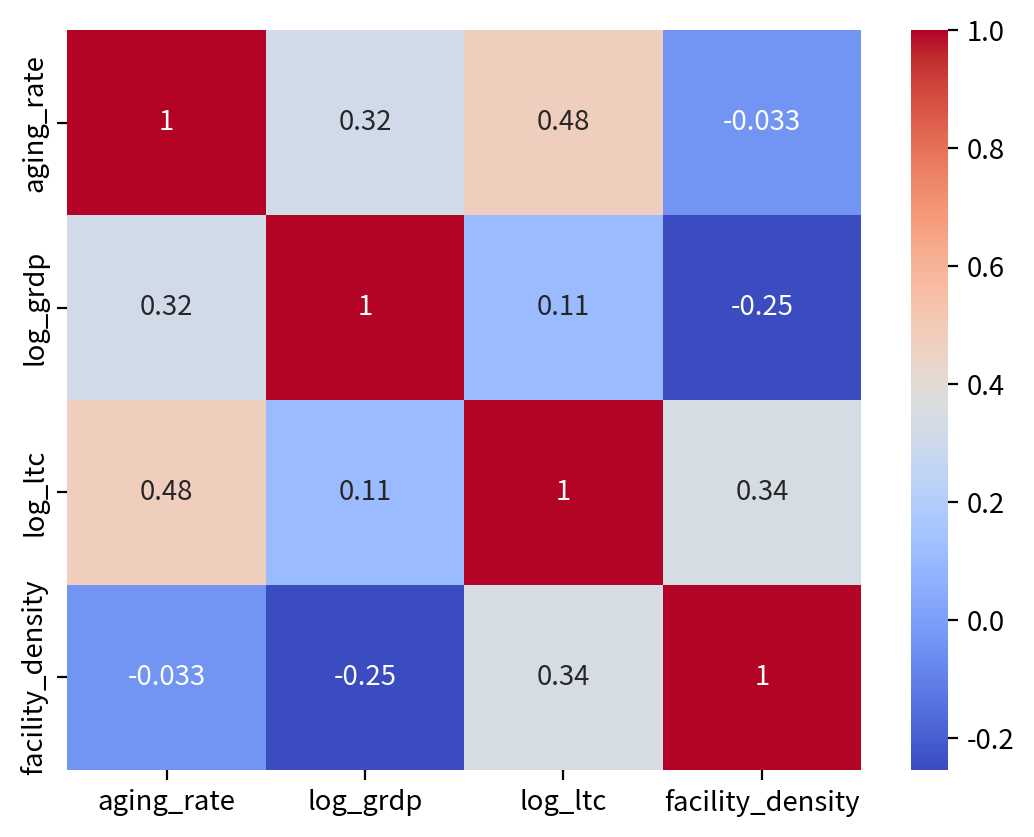

In [344]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    final_panel[['aging_rate','log_grdp','log_ltc','facility_density']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

### 2. 다중공선성 확인(VIF)

In [348]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
x = final_panel[['aging_rate','log_grdp','facility_density']]
x = sm.add_constant(x)

vif_dict = {
    col: variance_inflation_factor(x.values, i)
    for i, col in enumerate(x.columns)
}

print(vif_dict)

{'const': 1278.7559542624408, 'aging_rate': 1.1157466581180848, 'log_grdp': 1.1906881012852397, 'facility_density': 1.071201375089354}


#### 인사이트
- 독립변수끼리 비교하였을 때, 다중공선성(VIF)값은 < 5 이므로 진행 ㄱㄱ
- post_2017은 정책 더미 변수이며 동시에 통제변수로 사용

## 5. Pooled OLS(기본 회귀)
### 1. 기본 관계 분석
- 패널 데이터를 일반 회귀처럼 취급하는 모델
- region x year 구조를 무시하고 전체 관측치로 보는 모델
- 패널 분석 진행 순서: Pooled OLS(패널 구조 무시) -> Fixed Effects(지역 고정효과 통제) -> Random Effects(랜덤 효과)
    - 패널 효과가 실제로 존재하는가에 대해 확인하기 위해

- Fixed Effects(지역 고정효과): 서울은 원래 노인이 많아 의료 이용이 높을 수 있다. 이게 '서울 특성'이며 LTC 증가의 원인이 될 수 있다. 그래서 OLS -> Fixed Effects 해서 비교

In [347]:
import statsmodels. formula.api as smf
ols = smf.ols(
    'log_ltc ~ aging_rate + log_grdp + post_2017 + facility_density',
    data=final_panel
).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                log_ltc   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     37.65
Date:                    월, 16 3 2026   Prob (F-statistic):           1.40e-24
Time:                        17:52:49   Log-Likelihood:                -306.83
No. Observations:                 252   AIC:                             623.7
Df Residuals:                     247   BIC:                             641.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           16.5988      2.044  

#### 인사이트
- 모델 유의성
- F-statistic: 34.71
- Prob(F-statistic): 8.62e-19
   - --> 설명변수들이 종속변수(log_ltc)에 영향을 주지 않는다. 즉, 모델 전체는 유의하다

--------------------------
- 설명력 (R^2)
- R-squared: 0.296
- Adj, R-squared: 0.288
   - --> 이 모델은 장기요양보험 지출 변동의 약 30%를 설명한다
--------------------------
- 핵심 변수 해석
- aging_rate
- coef = 0.1028
- p-value < 0.001
   - --> 고령화율이 1%p 증가하면 장기요양보험 지출은 약 10.3% 증가한다
   - 즉, 고령화율 상승이 장기요양보험 지출 증가의 강력한 설명 변수(노인 인구 증가 -> 요양서비스 이용 증가 증명)
--------------------------
- facility_density
- coef = 0.5589
- p-value < 0.001
   - --> 노인 대비 요양기관 공급이 증가할수록 LTC 지출 증가(공급 확대 -> 서비스 이용 증가 -> LTC지출 증가)
--------------------------
- log_grdp
- coef = -0.0431
- p = 0.820
   - --> 지역 경제력(grdp)는 LTC 지출과 통계적으로 유의한 관계 없음
--------------------------
- post_2017
- coef = 0.3529(로그 모델이므로 풀어주면 1.42)
- p = 0.008
   - --> 2017년 정책 이후 LTC 지출 약 42% 증가
   - --> 장기요양 등급 개편의 가능성이 있음
--------------------------
- 잔차 정규성
- Prob(JB): 5.50e-08
   - --> 정규성은 약간 깨져 있으나 표본 수(253)이므로 중심극한정리에 의해 큰 문제는 아니다(표본수가 충분히 크다)
--------------------------
- Durbin-Watson
- 0.198
   - --> 강한 양의 자기상관
   - --> OLS -> FE/RE 패널모델로 가는 근거  

## 6. Fixed Effects
### 1. 인덱스 설정

In [349]:
final_panel2 = final_panel.set_index(['region','year'])
final_panel2

aging_rate  total_pop   grdp      ltc_cost     cpi  post_2017  \
region  year                                                                  
강원특별자치도 2010      14.413     217936  21906 105484247.880  86.373          0   
        2011      14.839     226863  22660 116822620.000  89.850          0   
        2012      15.238     233959  23566 127217385.000  91.815          0   
        2013      15.769     242479  24751 143271393.000  93.010          0   
        2014      16.241     250238  26351 165902722.000  94.196          0   
...                  ...        ...    ...           ...     ...        ...   
충청북도    2020      17.182     274813  46462 371894584.100 100.000          1   
        2021      18.106     289635  49519 423426688.370 102.500          1   
        2022      18.997     303393  52252 472467914.910 107.720          1   
        2023      19.975     318500  53827 538519859.710 111.590          1   
        2024      20.961     333737  56328 603200375.380 114.180          1   

                  ltc_real  log_ltc  facility_count  facility_density  \
region  year                                                            
강원특별자치도 2010 139443939.923   18.753             514             2.358   
        2011 148456391.225   18.816             577             2.543   
        2012 158205968.734   18.879             567             2.424   
        2013 175881385.364   18.985             596             2.458   
        2014 201099545.607   19.119             623             2.490   
...                    ...      ...             ...               ...   
충청북도    2020 424629236.125   19.867             913             3.322   
        2021 471676675.884   19.972             971             3.352   
        2022 500801954.367   20.032            1047             3.451   
        2023 551018886.833   20.127            1083             3.400   
        2024 603200375.380   20.218            1106             3.314   

              log_grdp  
region  year            
강원특별자치도 2010     9.995  
        2011    10.028  
        2012    10.068  
        2013    10.117  
        2014    10.179  
...                ...  
충청북도    2020    10.746  
        2021    10.810  
        2022    10.864  
        2023    10.894  
        2024    10.939  

[252 rows x 11 columns]

### 2. Fixed Effects 확인

In [350]:
from linearmodels.panel import PanelOLS

fe_model = PanelOLS.from_formula(
    'log_ltc ~ aging_rate + log_grdp + post_2017 + + facility_density + EntityEffects',
    data = final_panel2
).fit(cov_type = 'robust')

print(fe_model.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_ltc   R-squared:                        0.9185
Estimator:                   PanelOLS   R-squared (Between):              0.3921
No. Observations:                 252   R-squared (Within):               0.9185
Date:                    월, 3 16 2026   R-squared (Overall):              0.3925
Time:                        18:05:03   Log-likelihood                    117.36
Cov. Estimator:                Robust                                           
                                        F-statistic:                      651.22
Entities:                          17   P-value                           0.0000
Avg Obs:                       14.824   Distribution:                   F(4,231)
Min Obs:                       12.000                                           
Max Obs:                       15.000   F-statistic (robust):             1363.3
                            

#### 인사이트

- 1. 모델 설명력(R-squared(within)): 0.9185
    - 같은 지역 내에서 시간 변화 기준으로 LTC 변동 약 91.8%를 설명
    - 즉, aging_rate + log_grdp + post_2017이 시간에 따른 LTX 변화 대부분을 설명
    - 패널 연구에서는 0.9 이상 값은 매우 높은 설명력을 가진 모델을 의미

- 2. R-squred(Between), R-squred(Overall)
    - 이 값들은 FE 모델에서는 지역 간 차이를 제거하였기 때문에 낮아지는 것이 정상

- 3. 모델 전체 유의성(F-statistic: 721.12, P-value: 0.000)
    - 가설 
        - H0: 모든 계수 = 0
    - P-value: 0.000
- --> 모델 전체가 유의함

- 4. 핵심 변수 해석(coef = Parameter)
- aging_rate
    - coef: 0.1061
    - p: 0.000
- --> 매우 유의하며, 고령화율이 1%p 증가하면 LTC 지출이 약 10.6% 증가
- --> 이는 POOLED OLS 결과값보다 효과가 더 커짐을 알 수 있다(지역 특성을 제거하였기 때문).

- log_grdp
    - coef: 0.157
    - p: 0.427
- --> 유의하지 않으며, 지역 내 GRDP 변화는 LTC 지출 변화와 통계적으로 관계 없음(경제 수준 변화 <<<<<< 고령화)

- Included effects: Entity
    - 같은 시간에 변하지 않은 지역 특징 제거
    -
- post_2017
    - coef: 0.386
    - p: 0.000
- --> LTC지출이 개편 후 38.6%증가
- facility+_density
    - coef: 0.305
    - p: 0.000
- --> 시설 밀도 증가 -> LTC 지출 증가(공급 증가가 수요를 유발하는 구조일 가능성)

핵심 결과

1️⃣ 고령화율은 장기요양보험 지출 증가의 가장 강력한 요인

2️⃣ 2017년 정책 이후
보험 지출이 구조적으로 증가

3️⃣ 시설 밀도 증가도
보험 지출 증가와 유의한 관계

4️⃣ 지역 경제력은
통계적으로 유의하지 않음

- FE 모델 구조: LTC = aging_rate, grdp + 지역 고정효과 + 오차
    - FE는 지역 평균을 뺴는 방식을 사용
    - ex) aging_rate avg = 10, LTC 평균 = 110 이면 이 기준을 따라 FE는 차이를 나타냄
    - 즉, 진짜 시간 변화 효과만 본다

### 3. Random Effects 실행

In [180]:
from linearmodels.panel import RandomEffects

re_model = RandomEffects.from_formula(
    'log_ltc ~ aging_rate + log_grdp + post_2017',
    data=final_panel2
).fit(cov_type='robust')

print(re_model.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                log_ltc   R-squared:                        0.9516
Estimator:              RandomEffects   R-squared (Between):              0.9961
No. Observations:                 252   R-squared (Within):               0.8579
Date:                    금, 3 13 2026   R-squared (Overall):              0.9961
Time:                        17:04:24   Log-likelihood                    40.103
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1630.2
Entities:                          17   P-value                           0.0000
Avg Obs:                       14.824   Distribution:                   F(3,249)
Min Obs:                       12.000                                           
Max Obs:                       15.000   F-statistic (robust):             1895.5
                            

#### 인사이트
- aging_rate 
    - coef: 0.0250
    - p: 0.101
- --> 통계적으로 유의하지 않음

- log_grdp
    - coef: 1.749
    - p: 0.000
- --> 매우 유의하나, GRDP 1% 증가하면 LTC 지출은 1.75% 증가. 이는 비정상적으로 큰값임

- post_2017
    - coef: 0.371 --> 약 45%
    - p: 0.000

- RE 모델 가정: region effect 와 aging_rate, grdp는 독립이라고 가정함
- 실제 데이터는 강하게 연결되어있다. 즉, RE 가정이 깨진다.

### 4. Hausman test

In [181]:
from scipy import stats

# 계수 차이
b = fe_model.params - re_model.params

# 공분산 차이
V = fe_model.cov - re_model.cov

# Hausman statistic
stat = np.dot(np.dot(b.T, np.linalg.inv(V)), b)

# 자유도
df = len(b)

# p-value
p = 1 - stats.chi2.cdf(stat, df)

print("Hausman statistic:", stat)
print("p-value:", p)

Hausman statistic: 56.939281522400606
p-value: 2.647770891428536e-12


#### 인사이트
- p-value < 0.05 이므로, H0 기각 H1 채택 --> Fixed Effects 선택
- 이유: Hausman test는 지역 고정효과와 독립변수 사이에 상관관계 존재함을 의미함. 그래서 RE 가정(독립성)이 깨짐
- 총 결과: 고령화율이 높아질수록 LTC 지출 높아짐. 2017년 정책 변경 이후 LTC 지출 증가, 지역 고정효과 존재
- Hausman test 결과 통계량은 56.94, p-value는 2.65×10⁻¹²로 나타났다. 이는 Random Effects 모형의 귀무가설을 기각하는 결과로, 지역 고정효과가 독립변수와 상관관계를 가진다는 것을 의미한다. 따라서 Random Effects 모형의 가정이 성립하지 않으며, Fixed Effects 모형이 더 적합한 것으로 판단된다. 이에 따라 본 연구에서는 지역별 고정효과를 통제한 Fixed Effects 패널 회귀모형을 최종 분석 모형으로 선택하였다. 
- Fixed Effects 모형 결과, 고령화율은 장기요양보험 지출 증가와 유의한 양(+)의 관계를 보였다.

## 7. 2017 이후 구조 파악 - interaction
### 1. interaction 변수 생성

In [359]:
final_panel2 = final_panel2.set_index(["region", "year"]).sort_index()
final_panel2['aging_post'] = final_panel2['aging_rate'] * final_panel2['post_2017']
display(final_panel2)

aging_rate  total_pop   grdp      ltc_cost     cpi  post_2017  \
region  year                                                                  
강원특별자치도 2010      14.413     217936  21906 105484247.880  86.373          0   
        2011      14.839     226863  22660 116822620.000  89.850          0   
        2012      15.238     233959  23566 127217385.000  91.815          0   
        2013      15.769     242479  24751 143271393.000  93.010          0   
        2014      16.241     250238  26351 165902722.000  94.196          0   
...                  ...        ...    ...           ...     ...        ...   
충청북도    2020      17.182     274813  46462 371894584.100 100.000          1   
        2021      18.106     289635  49519 423426688.370 102.500          1   
        2022      18.997     303393  52252 472467914.910 107.720          1   
        2023      19.975     318500  53827 538519859.710 111.590          1   
        2024      20.961     333737  56328 603200375.380 114.180          1   

                  ltc_real  log_ltc  facility_count  facility_density  \
region  year                                                            
강원특별자치도 2010 139443939.923   18.753             514             2.358   
        2011 148456391.225   18.816             577             2.543   
        2012 158205968.734   18.879             567             2.424   
        2013 175881385.364   18.985             596             2.458   
        2014 201099545.607   19.119             623             2.490   
...                    ...      ...             ...               ...   
충청북도    2020 424629236.125   19.867             913             3.322   
        2021 471676675.884   19.972             971             3.352   
        2022 500801954.367   20.032            1047             3.451   
        2023 551018886.833   20.127            1083             3.400   
        2024 603200375.380   20.218            1106             3.314   

              log_grdp  aging_post  
region  year                        
강원특별자치도 2010     9.995       0.000  
        2011    10.028       0.000  
        2012    10.068       0.000  
        2013    10.117       0.000  
        2014    10.179       0.000  
...                ...         ...  
충청북도    2020    10.746      17.182  
        2021    10.810      18.106  
        2022    10.864      18.997  
        2023    10.894      19.975  
        2024    10.939      20.961  

[252 rows x 12 columns]

### 2. 데이터 merge

In [360]:
X = final_panel2[["aging_rate","post_2017","aging_post","log_grdp","facility_density"]]
X = sm.add_constant(X)

y = final_panel2["log_ltc"]

model = PanelOLS(y, X, entity_effects=True)

result = model.fit(cov_type="robust")

print(result.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_ltc   R-squared:                        0.9276
Estimator:                   PanelOLS   R-squared (Between):              0.1712
No. Observations:                 252   R-squared (Within):               0.9276
Date:                    월, 3 16 2026   R-squared (Overall):              0.3497
Time:                        18:14:39   Log-likelihood                    132.24
Cov. Estimator:                Robust                                           
                                        F-statistic:                      589.49
Entities:                          17   P-value                           0.0000
Avg Obs:                       14.824   Distribution:                   F(5,230)
Min Obs:                       12.000                                           
Max Obs:                       15.000   F-statistic (robust):             1607.2
                            

#### 인사이트
- aging_rate
    - coef: 0.1371
    - p: 0.000
        - 통계적으로 매우 유의

- 해석

- 고령화율이 1%p 증가할 때 장기요양보험(LTC) 지출은 약 13.7% 증가 → 고령화는 LTC 지출 증가의 핵심 요인

- post_2017
    - coef: 0.6312
    - p: 0.000
        - 통계적으로 매우 유의

- 해석

- 2017년 정책 이후 LTC 지출 수준이 구조적으로 증가
    - exp(0.6312) ≈ 1.88
        → 정책 이후 LTC 지출 약 88% 증가

- aging_post (interaction)
    - coef: -0.0137
    - p: 0.041
        - 통계적으로 유의

- 해석

- 정책 이전 고령화 효과
    - aging_rate = 0.1371

- 정책 이후 고령화 효과
    - 0.1371 + (-0.0137) = 0.1234
        → 정책 이후 고령화가 LTC 지출에 미치는 영향이 약간 감소

- 즉, LTC 지출 증가가 단순 고령화보다 정책 확대 영향이 커졌을 가능성 존재

- log_grdp
    - coef: -0.1315
    - p: 0.457
        - 통계적으로 유의하지 않음

- 해석

- 지역 경제 규모(GRDP)는 LTC 지출 변화 설명에서 유의하지 않음
    가능한 이유
        지역 고정효과(FE)가 지역 경제 수준 차이를 이미 상당 부분 흡수했을 가능성


## 8. Threshold 분석 수행
### 1. piecewise regression 변수 추가
- ML에서도 Threshold가 나오기는 하지만, 뒷받침 할 근거가 많이 부족하다고 판단하여 선행과정을 통하여 그 이유를 자세히 찾고자 함

In [361]:
df3 = final_panel2.copy()

# piecewise 변수
df3["aging_over14"] = (df3["aging_rate"] - 14).clip(lower=0)

# threshold dummy
df3["over14_dummy"] = (df3["aging_rate"] > 14).astype(int)

display(df3)

aging_rate  total_pop   grdp      ltc_cost     cpi  post_2017  \
region  year                                                                  
강원특별자치도 2010      14.413     217936  21906 105484247.880  86.373          0   
        2011      14.839     226863  22660 116822620.000  89.850          0   
        2012      15.238     233959  23566 127217385.000  91.815          0   
        2013      15.769     242479  24751 143271393.000  93.010          0   
        2014      16.241     250238  26351 165902722.000  94.196          0   
...                  ...        ...    ...           ...     ...        ...   
충청북도    2020      17.182     274813  46462 371894584.100 100.000          1   
        2021      18.106     289635  49519 423426688.370 102.500          1   
        2022      18.997     303393  52252 472467914.910 107.720          1   
        2023      19.975     318500  53827 538519859.710 111.590          1   
        2024      20.961     333737  56328 603200375.380 114.180          1   

                  ltc_real  log_ltc  facility_count  facility_density  \
region  year                                                            
강원특별자치도 2010 139443939.923   18.753             514             2.358   
        2011 148456391.225   18.816             577             2.543   
        2012 158205968.734   18.879             567             2.424   
        2013 175881385.364   18.985             596             2.458   
        2014 201099545.607   19.119             623             2.490   
...                    ...      ...             ...               ...   
충청북도    2020 424629236.125   19.867             913             3.322   
        2021 471676675.884   19.972             971             3.352   
        2022 500801954.367   20.032            1047             3.451   
        2023 551018886.833   20.127            1083             3.400   
        2024 603200375.380   20.218            1106             3.314   

              log_grdp  aging_post  aging_over14  over14_dummy  
region  year                                                    
강원특별자치도 2010     9.995       0.000         0.413             1  
        2011    10.028       0.000         0.839             1  
        2012    10.068       0.000         1.238             1  
        2013    10.117       0.000         1.769             1  
        2014    10.179       0.000         2.241             1  
...                ...         ...           ...           ...  
충청북도    2020    10.746      17.182         3.182             1  
        2021    10.810      18.106         4.106             1  
        2022    10.864      18.997         4.997             1  
        2023    10.894      19.975         5.975             1  
        2024    10.939      20.961         6.961             1  

[252 rows x 14 columns]

### 2. FE 회귀 진행

In [362]:
X = df3[["aging_rate","aging_over14","post_2017","log_grdp"]]
X = sm.add_constant(X)

y = df3["log_ltc"]

model = PanelOLS(y, X, entity_effects=True)
result = model.fit(cov_type="robust")

print(result)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_ltc   R-squared:                        0.9032
Estimator:                   PanelOLS   R-squared (Between):              0.0637
No. Observations:                 252   R-squared (Within):               0.9032
Date:                    월, 3 16 2026   R-squared (Overall):              0.2670
Time:                        18:15:06   Log-likelihood                    95.662
Cov. Estimator:                Robust                                           
                                        F-statistic:                      539.07
Entities:                          17   P-value                           0.0000
Avg Obs:                       14.824   Distribution:                   F(4,231)
Min Obs:                       12.000                                           
Max Obs:                       15.000   F-statistic (robust):             1295.6
                            

#### 인사이트
- 고령화 사회 기준(14%)로 임의로 잡고 분석 수행
- aging_rate, aging_over14로 볼 때, 2010~2024년 기간동안 임계점이 존재한다는 통계적 증거 없다
- 요약
    - 2010–2024년 기간 동안 고령화율과 장기요양급여 지출은 유의한 양(+)의 관계를 보였으나, 고령사회 기준(14%)을 기준으로 한 임계점 효과는 통계적으로 확인되지 않았다.
    - 정책적 측면: LTC 지출 증가는 특정 고령화 수준에서 갑자기 발생하기보다 고령화율 증가에 따라 지속적으로 나타나는 구조적 현상일 가능성이 있다.

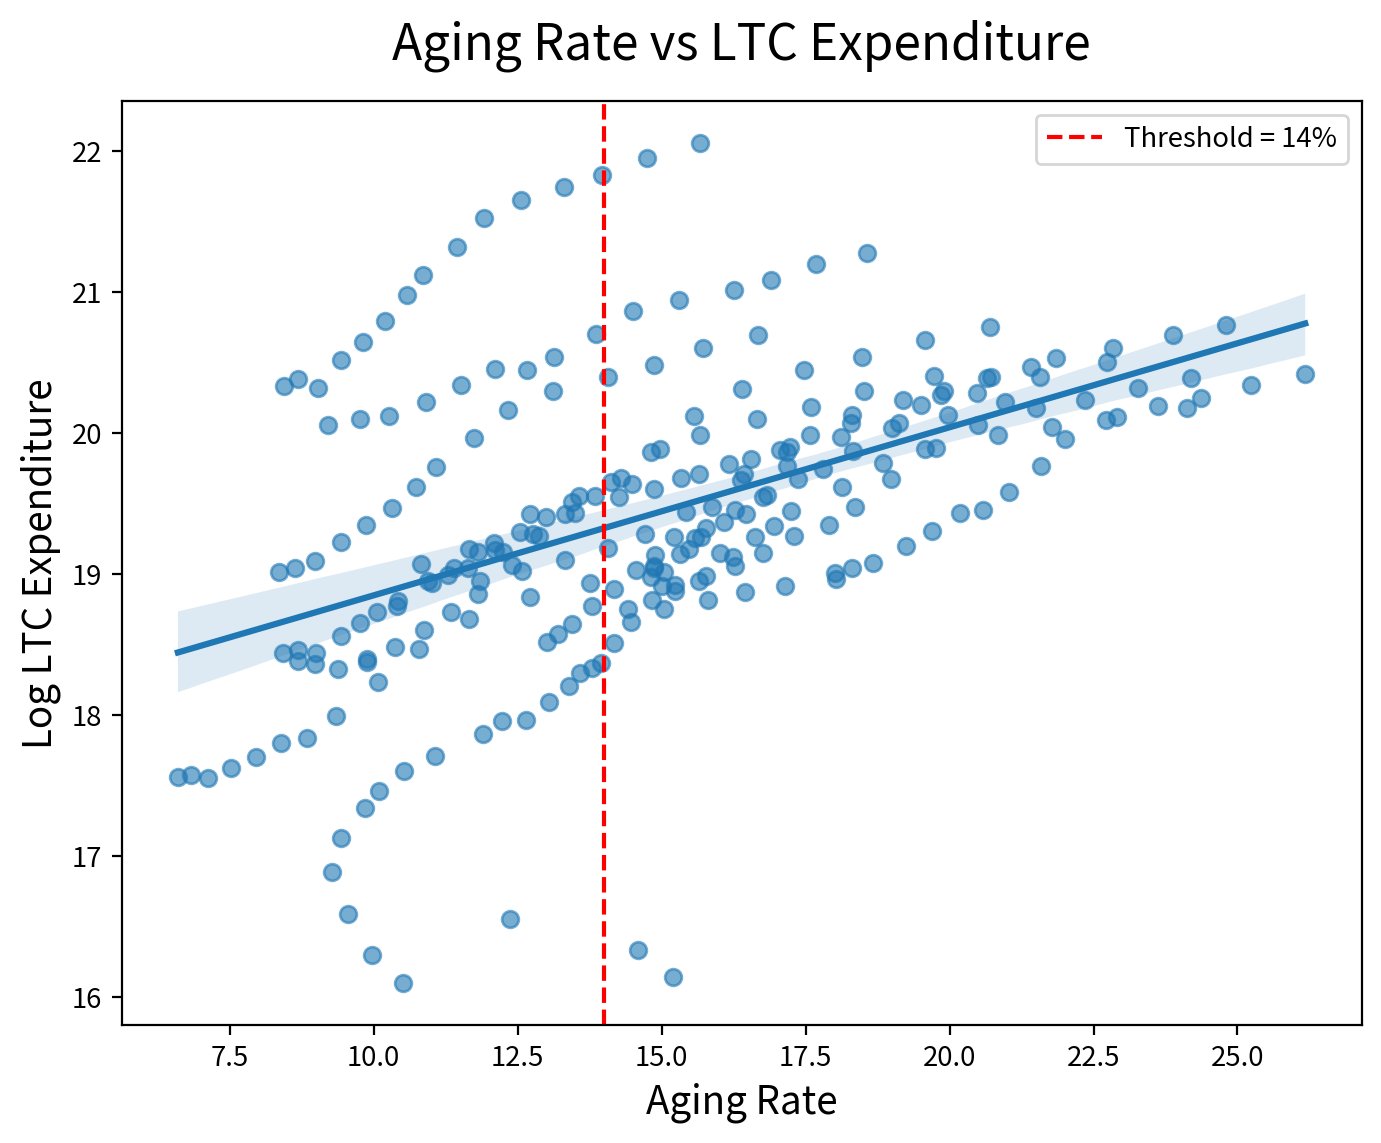

In [363]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    x="aging_rate",
    y="log_ltc",
    data=df3,
    scatter_kws={"alpha":0.6}
)

# threshold line
plt.axvline(x=14, color="red", linestyle="--", label="Threshold = 14%")

plt.xlabel("Aging Rate")
plt.ylabel("Log LTC Expenditure")
plt.title("Aging Rate vs LTC Expenditure")

plt.legend()
plt.show()

#### 인사이트
- Threshold Test (14%)로 진행을 하였을 때,
    - 고령사회 기준(14%)에서 구조적 변화 확인되지 않음
    - LTC 지출은 고령화율 증가에 따라 지속적으로 증가(양의 관계)
    - 급격한 패턴 변화는 관찰되지 않음 

### 3. region 구분 추가

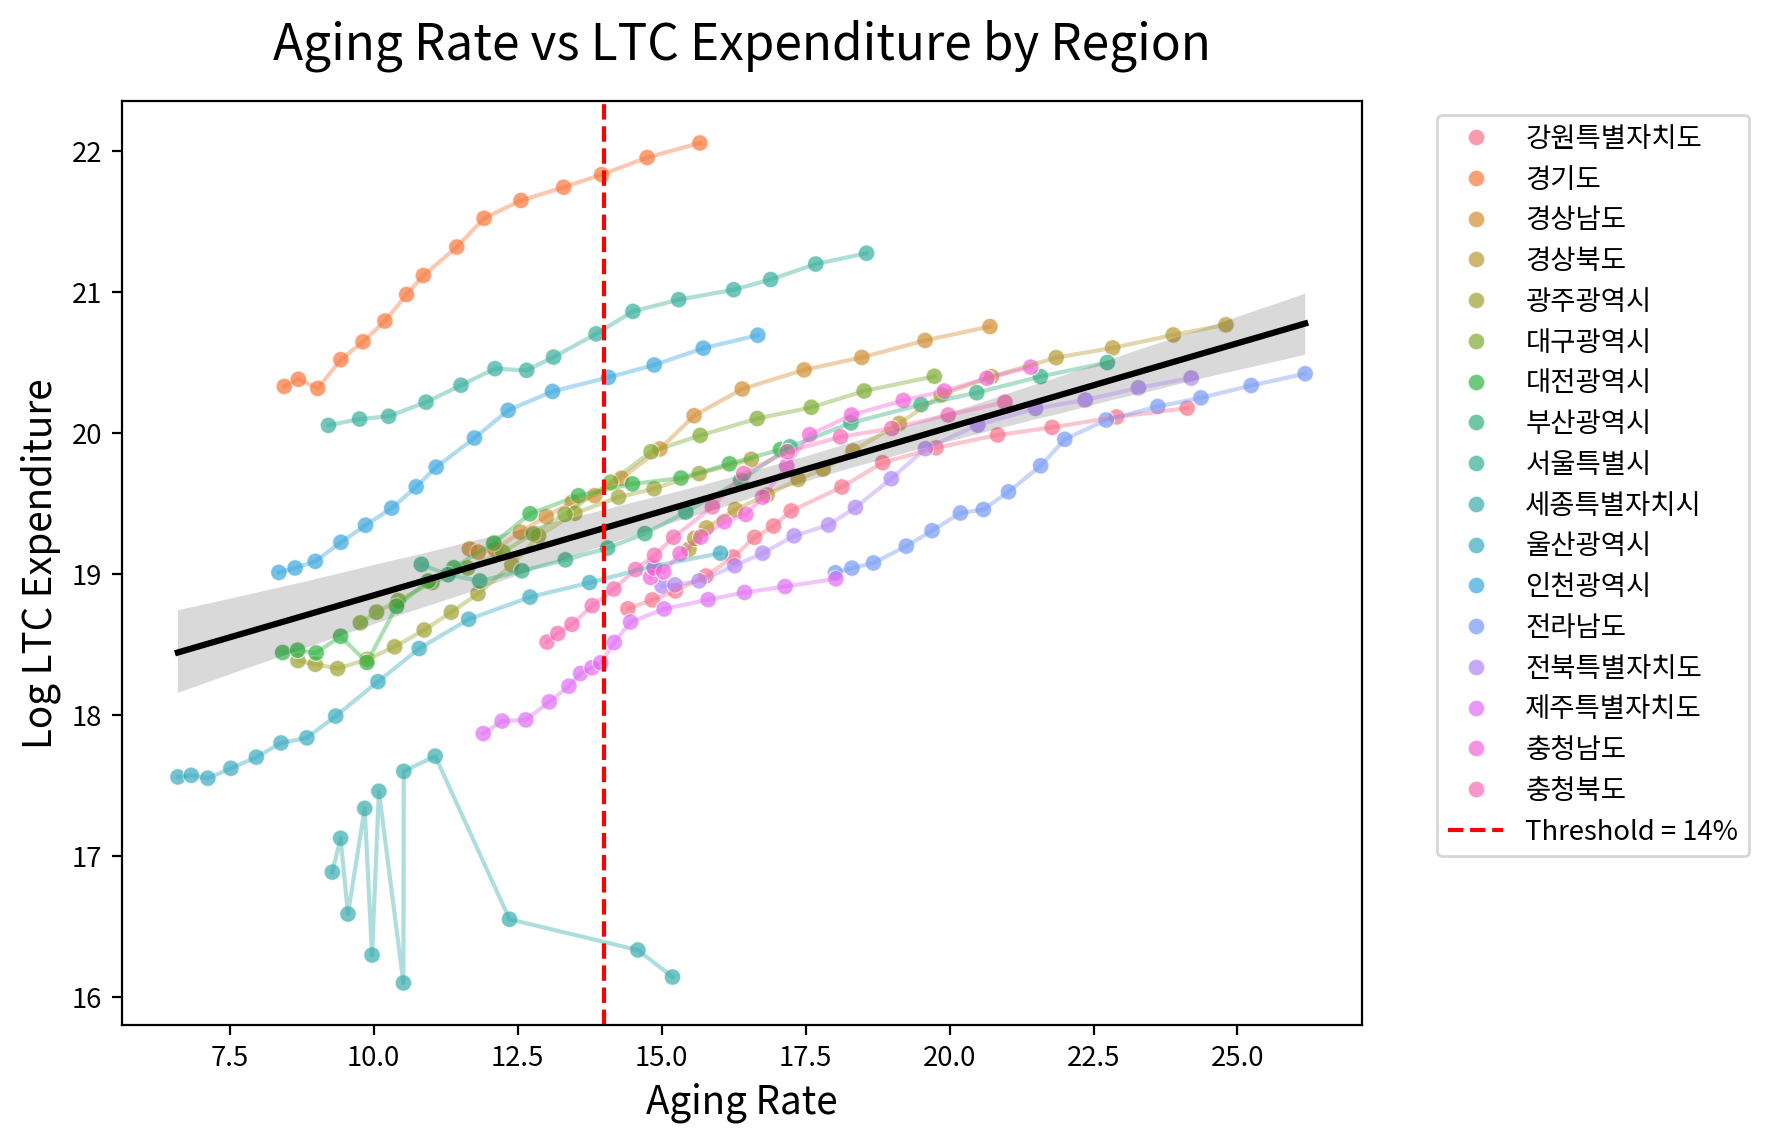

In [364]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="aging_rate",
    y="log_ltc",
    hue="region",
    data=df3,
    alpha=0.7
)

# 지역별 선 연결
sns.lineplot(
    x="aging_rate",
    y="log_ltc",
    hue="region",
    data=df3,
    alpha=0.4,
    legend=False   # legend 중복 방지
)

# 전체 추세선
sns.regplot(
    x="aging_rate",
    y="log_ltc",
    data=df3,
    scatter=False,
    color="black"
)

# threshold line
plt.axvline(x=14, color="red", linestyle="--", label="Threshold = 14%")

plt.xlabel("Aging Rate")
plt.ylabel("Log LTC Expenditure")
plt.title("Aging Rate vs LTC Expenditure by Region")

plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

## 9. Machine Learning
### 1. Pycarat set up
#### 1. (Region 제외)

In [365]:
df4 = df3.copy()
df4 = df3.reset_index()
df4 = df4.drop(columns = ['region'])
display(df4)

,year,aging_rate,total_pop,grdp,ltc_cost,cpi,post_2017,ltc_real,log_ltc,facility_count,facility_density,log_grdp,aging_post,aging_over14,over14_dummy
0,2010,14.413,217936,21906,105484247.880,86.373,0,139443939.923,18.753,514,2.358,9.995,0.000,0.413,1
1,2011,14.839,226863,22660,116822620.000,89.850,0,148456391.225,18.816,577,2.543,10.028,0.000,0.839,1
2,2012,15.238,233959,23566,127217385.000,91.815,0,158205968.734,18.879,567,2.424,10.068,0.000,1.238,1
3,2013,15.769,242479,24751,143271393.000,93.010,0,175881385.364,18.985,596,2.458,10.117,0.000,1.769,1
4,2014,16.241,250238,26351,165902722.000,94.196,0,201099545.607,19.119,623,2.490,10.179,0.000,2.241,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,2020,17.182,274813,46462,371894584.100,100.000,1,424629236.125,19.867,913,3.322,10.746,17.182,3.182,1
248,2021,18.106,289635,49519,423426688.370,102.500,1,471676675.884,19.972,971,3.352,10.810,18.106,4.106,1
249,2022,18.997,303393,52252,472467914.910,107.720,1,500801954.367,20.032,1047,3.451,10.864,18.997,4.997,1
250,2023,19.975,318500,53827,538519859.710,111.590,1,551018886.833,20.127,1083,3.400,10.894,19.975,5.975,1


In [366]:
from pandas import concat
from pycaret.regression import *

s = RegressionExperiment()
s.setup(
    ### 기본설정(필수 지정)
    #### 데이터셋 지정
    data = df4,
    #### 예측목표 변수 지정
    target = 'log_ltc',
    #### 랜덤 시드 고정
    session_id = 52,
    #### 훈련 데이터 비용(기본값 = 0.7)
    train_size = 0.75,
    #### 교차검증 폴드 수 지정
    fold = 5,
    #### 시간 순서 기반 CV 만들기
    fold_strategy = 'timeseries',
    #### 데이터 셔플 막기
    data_split_shuffle = False,
    fold_shuffle = False,
    #### 처리과정 출력 안함(기본값 True, False 권장, 출력 과정이 다소 길어질 수 있음)
    verbose = False,
    #### GPU 사용 여부 지정(기본값 False) - True로 설정시 컴퓨터 환경에 따라 지원 안될 경우 에러
    use_gpu = False,
    ### 전처리 설정(1)
    #### 범주형 변수 지정(기본값 None)
    # categorical_features = [None],
    #### 생략할 변수 지정(기본값 None)
    ignore_features = ['ltc_real', 'ltc_cost','grdp'],
    #### 데이터 정규화/표준화 활성화(기본값 False)
    normalize = True,
    #### 데이터 정규화/표준화 방법 선택(zscore가 StandardScaler와 동일)
    #### 'minmax', 'maxabs', 'robust', 'zscore'
    normalize_method = 'zscore',
    ### 전처리 설정(2)- 아래 기능은 사용하지 말고, 데이터 별도의 전처리 단계를 거치는 것을 권장
    #### 이상치 제거(기본값 False, IQR 범위 밖의 값을 삭제함)
    remove_outliers = False,
    #### 이상치 제거 임계값(기본값 0.05, 상하위 몇 %를 이상치로 간주할지 지정)
    outliers_threshold = 0.05,
    #### 종속변수 변환(기본값 False)
    transform_target = False,
    #### 변수 선택(기본값 False)
    feature_selection = False,
)

In [367]:
s.pull()

,Description,Value
0,Session id,52
1,Target,log_ltc
2,Target type,Regression
3,Original data shape,"(252, 15)"
4,Transformed data shape,"(252, 12)"
5,Transformed train set shape,"(189, 12)"
6,Transformed test set shape,"(63, 12)"
7,Ignore features,3
8,Numeric features,11
9,Preprocess,True


#### 2. 베이스 모델 구축하기


In [368]:
s.models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.ElasticNet,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPursuit,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


#### 3. 베이스 모델 성능 비교

In [ ]:
best5models = s.compare_models(sort = 'RMSE', n_select = 5)
best5models

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,18:15:39
Status,. . . . . . . . . . . . . . . . . .,Fitting 5 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Linear Regression


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)


Processing:   0%|          | 0/89 [00:00<?, ?it/s]

#### 4. 주요 모델만 선정하여 성능 비교

In [230]:
best5models = s.compare_models(include = ['lr','ridge','lasso','en','knn','svm','dt','xgboost','lightgbm','catboost','rf'], sort = 'RMSE', n_select = 5)
best5models

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,17:54:19
Status,. . . . . . . . . . . . . . . . . .,Loading Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,0.5225,0.7662,0.8173,0.1658,0.0416,0.0280,0.4660
knn,K Neighbors Regressor,0.5832,0.7246,0.8444,0.1741,0.0429,0.0311,0.0120
rf,Random Forest Regressor,0.5866,0.8963,0.8756,0.0392,0.0443,0.0312,0.0460
lightgbm,Light Gradient Boosting Machine,0.6769,0.8463,0.9043,0.0539,0.0457,0.0357,0.0440
svm,Support Vector Regression,0.6621,0.8320,0.9062,0.0526,0.0455,0.0347,0.0080
ridge,Ridge Regression,0.6796,0.9041,0.9487,-0.0672,0.0476,0.0358,0.0080
xgboost,Extreme Gradient Boosting,0.6133,1.1537,0.9843,-0.2280,0.0503,0.0328,0.0240
dt,Decision Tree Regressor,0.6331,1.2177,1.0044,-0.2966,0.0512,0.0337,0.0080
lasso,Lasso Regression,0.8116,1.0858,1.0341,-0.2763,0.0519,0.0423,0.0080
en,Elastic Net,0.8116,1.0858,1.0341,-0.2763,0.0519,0.0423,0.0080


 KNeighborsRegressor(n_jobs=-1),
 RandomForestRegressor(n_jobs=-1, random_state=52),
 LGBMRegressor(n_jobs=-1, random_state=52),
 SVR()]

## 10-1. 앙상블(region 제외)
### 1. 선정된 모형에 대한 Voting

In [194]:
blended = s.blend_models(estimator_list = best5models, fold = 5)
blended

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4558,0.4961,0.7043,0.2666,0.0368,0.0251
1,0.5364,0.4805,0.6932,0.4887,0.0356,0.0287
2,0.6456,1.0369,1.0183,0.0833,0.0526,0.0351
3,0.7280,1.0610,1.0300,-0.1396,0.0519,0.0383
4,0.4922,0.4173,0.6460,0.4069,0.0307,0.0244
Mean,0.5716,0.6983,0.8184,0.2212,0.0415,0.0303
Std,0.1009,0.2876,0.1692,0.2268,0.0090,0.0055


VotingRegressor(estimators=[('CatBoost Regressor',
                             <catboost.core.CatBoostRegressor object at 0x0000021DE8B7F950>),
                            ('K Neighbors Regressor',
                             KNeighborsRegressor(n_jobs=-1)),
                            ('Random Forest Regressor',
                             RandomForestRegressor(n_jobs=-1, random_state=52)),
                            ('Light Gradient Boosting Machine',
                             LGBMRegressor(n_jobs=-1, random_state=52)),
                            ('Support Vector Regression', SVR())],
                n_jobs=-1)

### 2. 하이퍼파라미터 확인(?)

In [195]:
%%time
tuned = s.tune_model(
    estimator = blended,
    optimize = 'RMSE',
    choose_better = True,
    verbose = False,
    early_stopping = True,

    # 하이퍼파라미터 탐색 방법(grid = 전체, random = 무작위)
    search_algorithm = 'random'
)

CPU times: total: 1.61 s
Wall time: 16.5 s


### 3. 분석 결과 확인
#### 1. 훈련, 검증 데이터 추출

In [196]:
# 원본 독립변수(분할전)
x = s.get_config('X')
y = s.get_config('y')

# 훈련 데이터(데이터 변환 전)
x_train = s.get_config('X_train')
y_train = s.get_config('y_train')

# 테스트 데이터(데이터 변환 전)
x_test = s.get_config('X_test')
y_test = s.get_config('y_test')

# 변환된 훈련 데이터
x_train_transformed = s.get_config('X_train_transformed')
y_train_transformed = s.get_config('y_train_transformed')

# 변환된 테스트 데이터
x_test_transformed = s.get_config('X_test_transformed')
y_test_transformed = s.get_config('y_test_transformed')

# 변환된 훈련+테스트 데이터 셋
x_transformed = concat([x_train_transformed, x_test_transformed])
y_transformed = concat([y_train_transformed, y_test_transformed])

(
(x.shape, y.shape), (x_train.shape, y_train.shape), (x_test.shape, y_test.shape), 
(x_train_transformed.shape, y_train_transformed.shape),
(x_test_transformed.shape, y_test_transformed.shape)
)

(((252, 8), (252,)),
 ((189, 8), (189,)),
 ((63, 8), (63,)),
 ((189, 8), (189,)),
 ((63, 8), (63,)))

### 2. 성능평가
#### 1. 시각화 초기화

In [197]:
init_pyplot()


✅ 시각화를 위한 한글 글꼴(NotoSansKR-Regular)이 자동 적용되었습니다.


#### 2. 성능평가 지표 확인

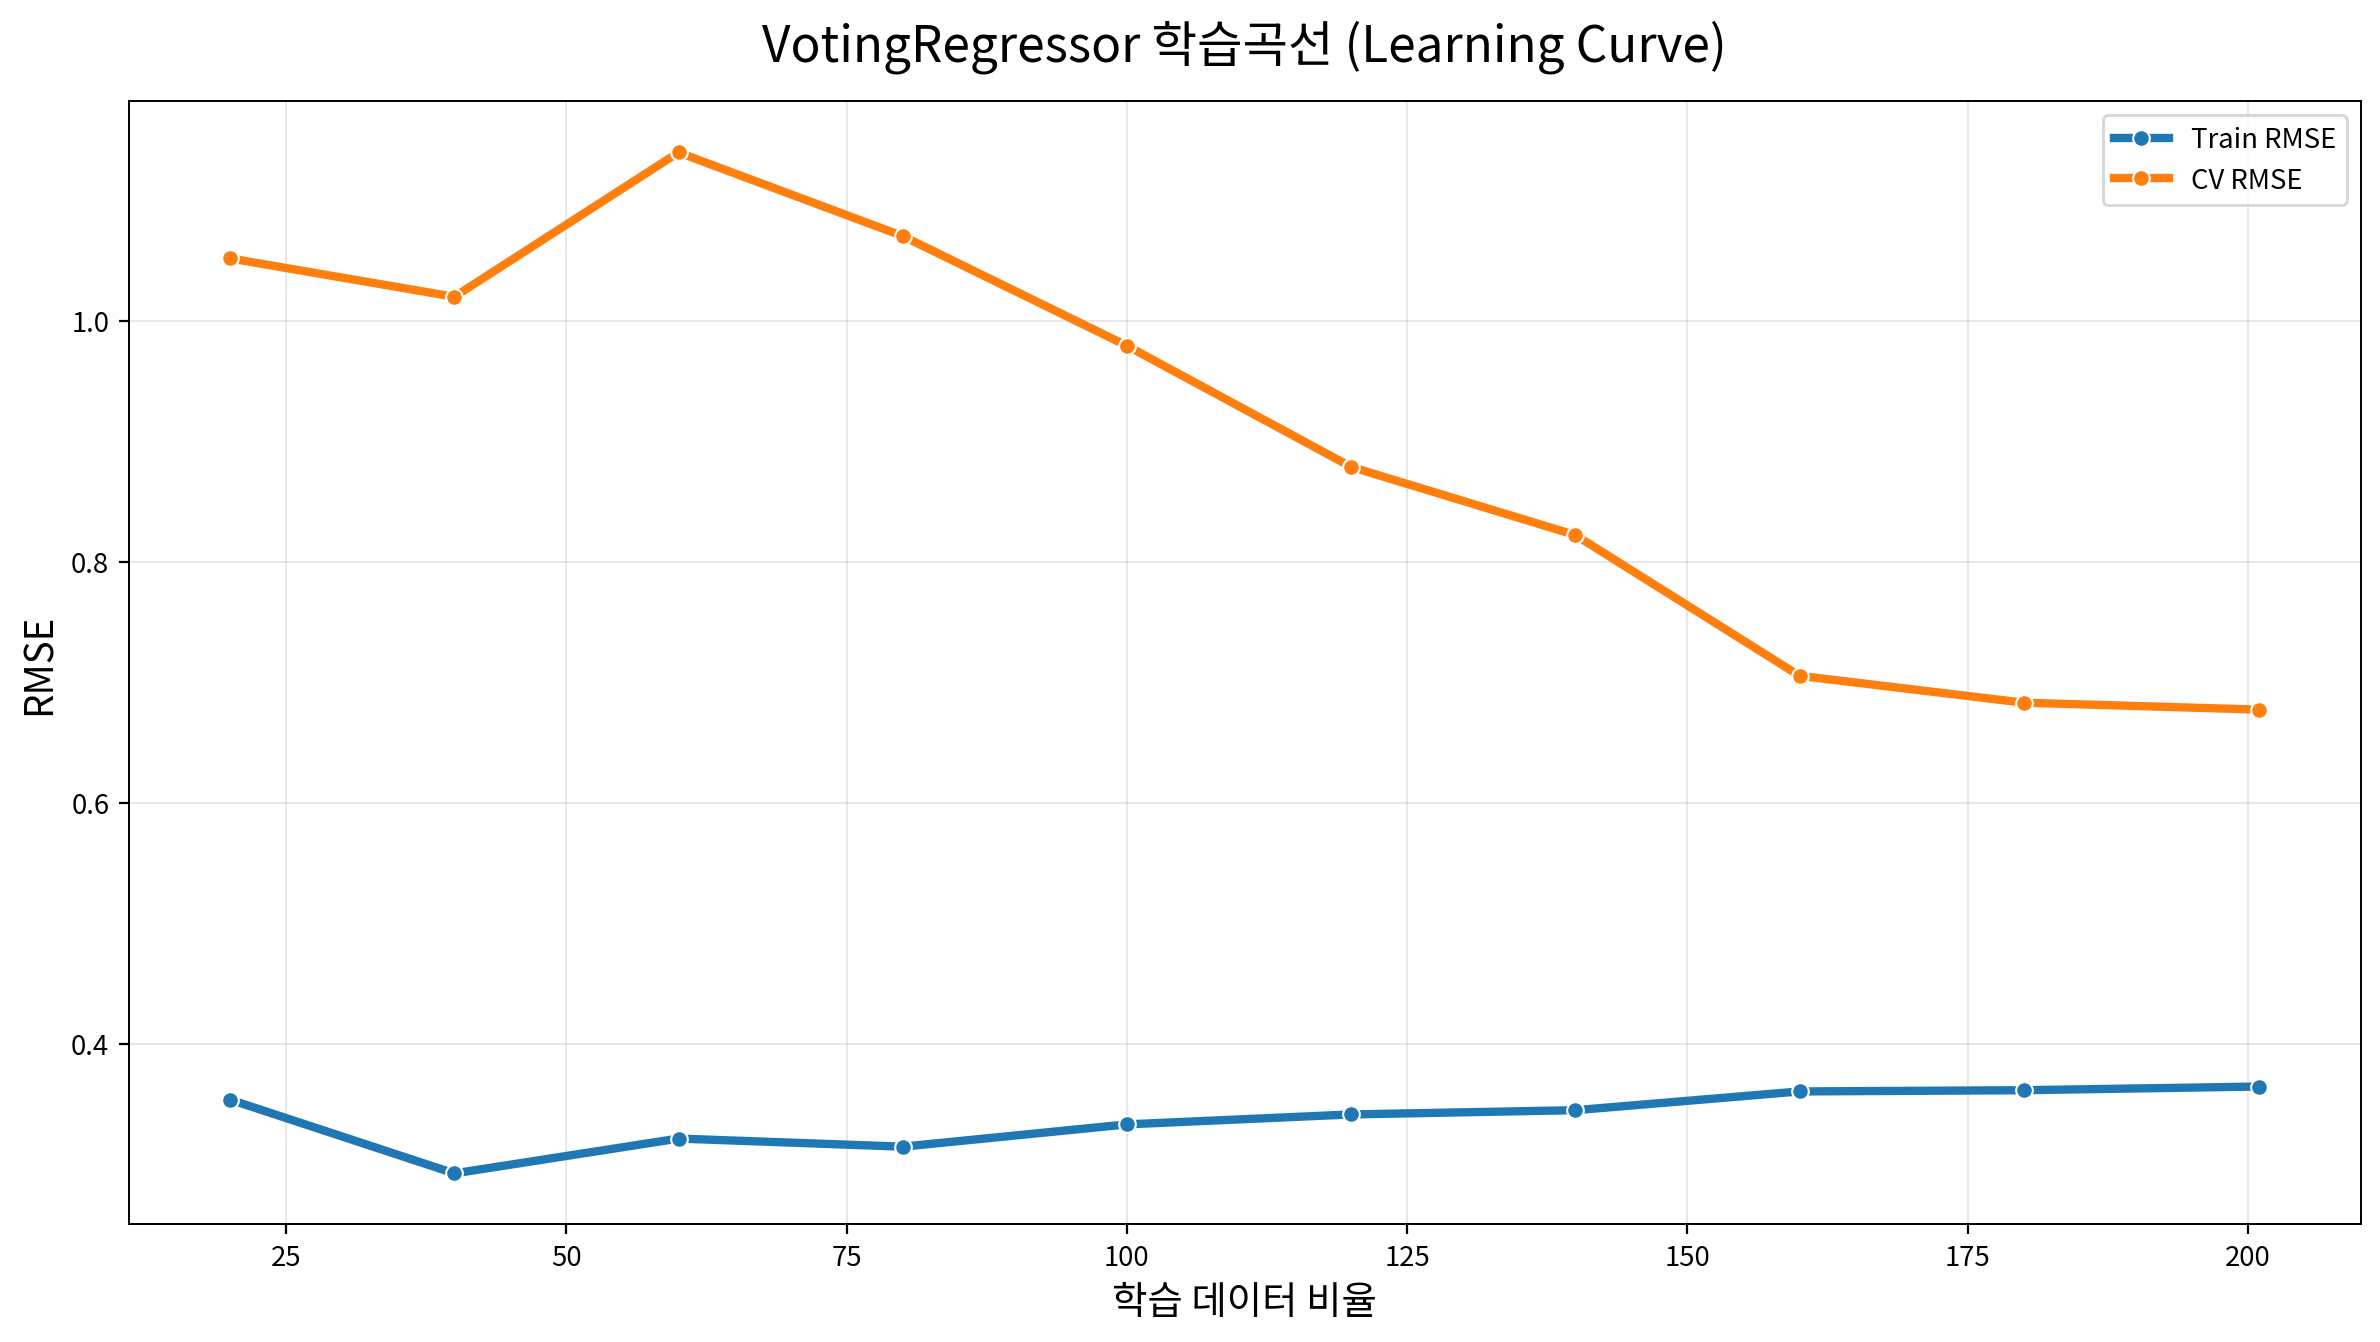

CPU times: total: 844 ms
Wall time: 21.9 s


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균제곱로그오차(MSLE),평균로그오차(RMSLE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
VotingRegressor,0.883,0.209,0.110,0.332,0.000,0.017,0.011,-0.113,0.365,0.677,0.144,0.538,0.212,⚠️ 데이터 추가시 일반화 기대


In [198]:
%%time
hs_get_score_cv(tuned, x_train_transformed, y_train_transformed, x_transformed, y_transformed)

#### 3. 변수 중요도 확인

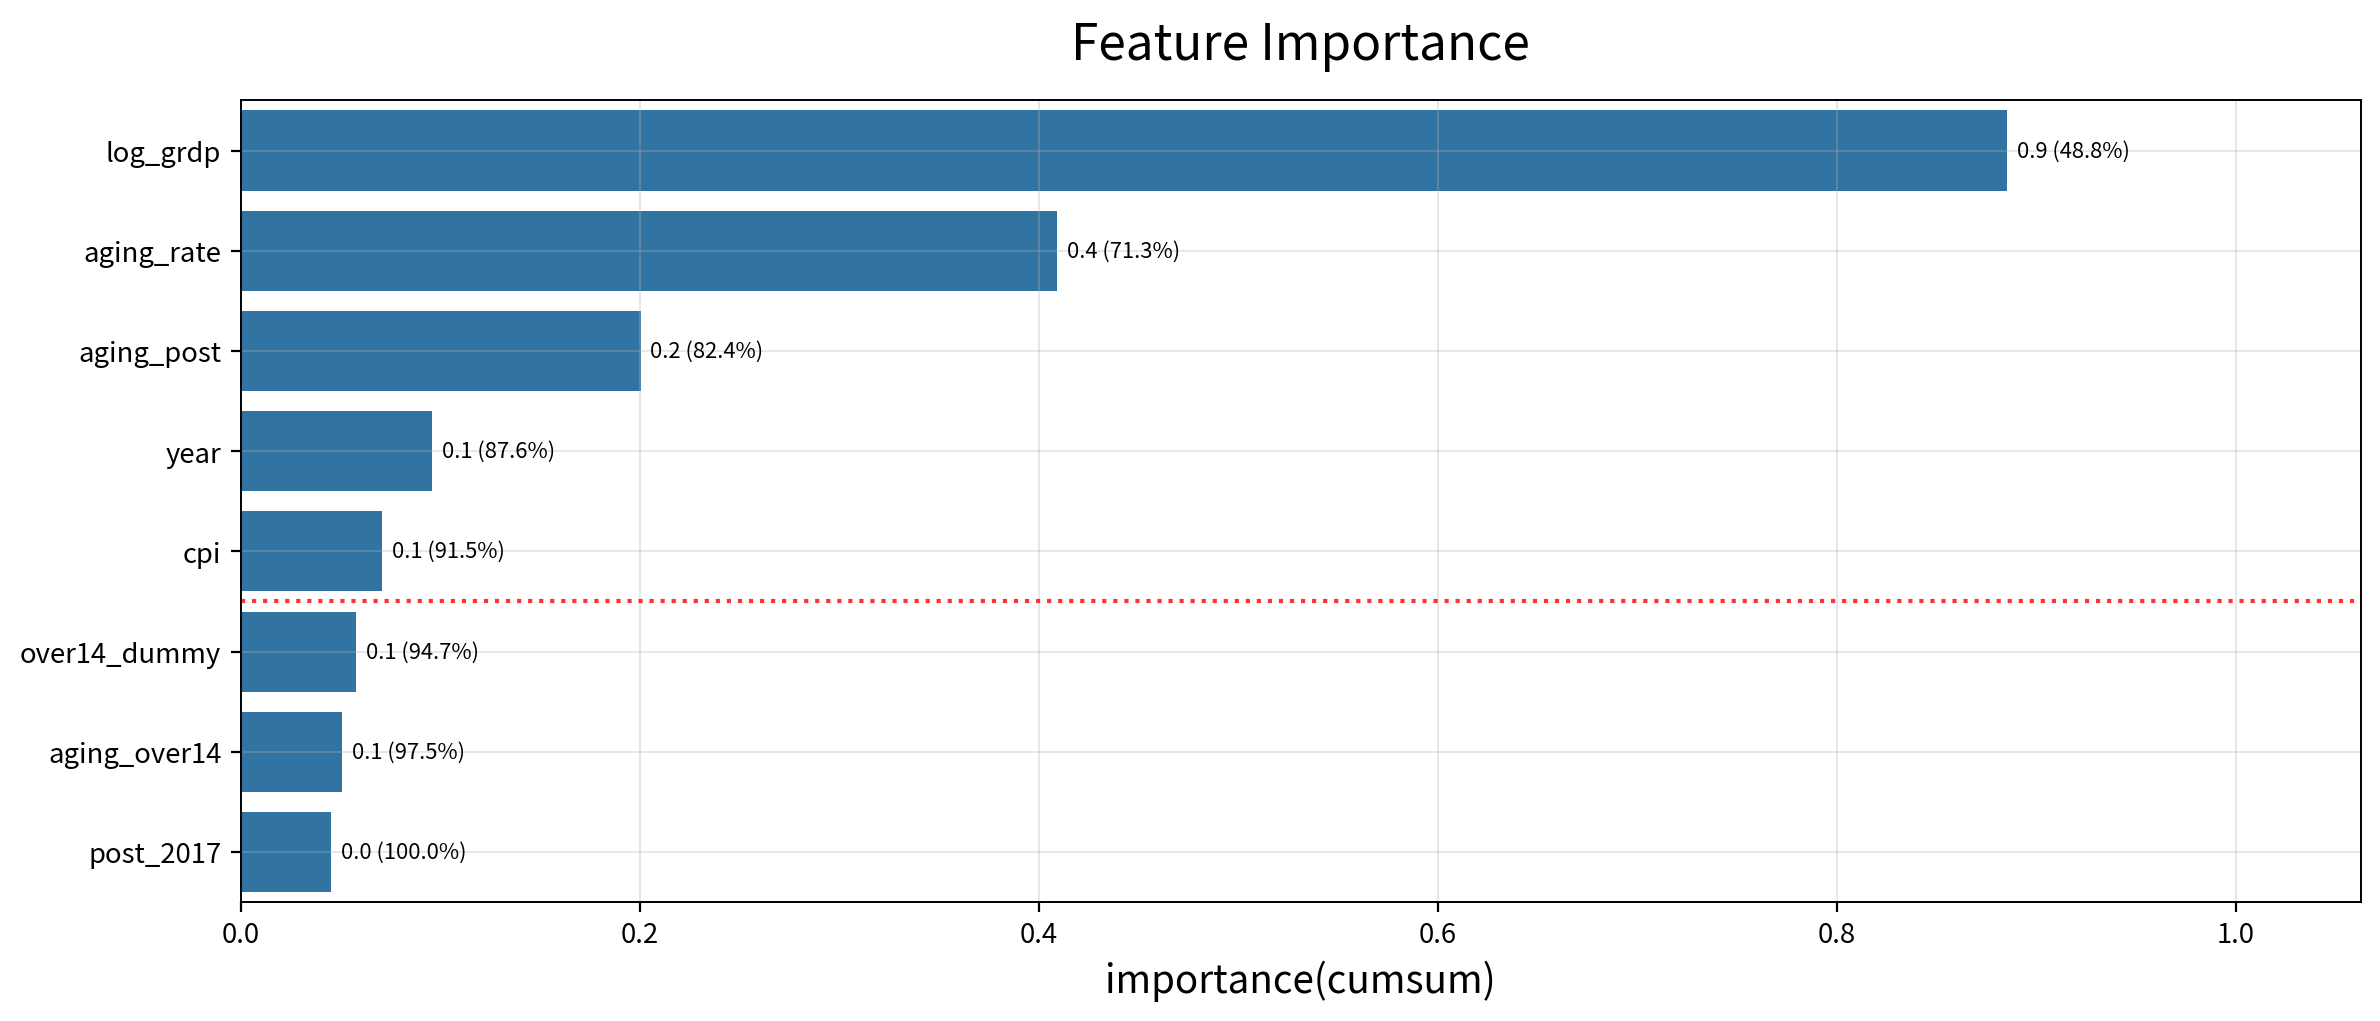

,importance,ratio,cumsum
log_grdp,0.886,0.488,0.488
aging_rate,0.409,0.225,0.713
aging_post,0.200,0.110,0.824
year,0.096,0.053,0.876
cpi,0.071,0.039,0.915
over14_dummy,0.058,0.032,0.947
aging_over14,0.051,0.028,0.975
post_2017,0.045,0.025,1.000


In [199]:
hs_feature_importance(tuned, x_train_transformed, y_train_transformed)

## 10-2. 앙상블(region 포함)
### 1. 선정된 모형에 대한 Voting

In [212]:
df5 = df3.copy()
df5 = df3.reset_index()
display(df5)

,region,year,aging_rate,grdp,ltc_cost,cpi,post_2017,ltc_real,log_ltc,log_grdp,aging_post,aging_over14,over14_dummy
0,서울특별시,2010,9.214,32407,387148917.000,86.373,0,511787981.696,20.053,10.386,0.000,0.000,0
1,부산광역시,2010,10.827,20459,144453176.420,86.373,0,190958559.777,19.068,9.926,0.000,0.000,0
2,대구광역시,2010,9.768,17526,95421098.570,86.373,0,126141051.425,18.653,9.771,0.000,0.000,0
3,인천광역시,2010,8.352,23871,136434657.820,86.373,0,180358552.208,19.010,10.080,0.000,0.000,0
4,광주광역시,2010,8.684,19867,73024072.310,86.373,0,96533506.725,18.385,9.897,0.000,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,전북특별자치도,2024,24.196,37980,715763531.820,114.180,1,715763531.820,20.389,10.545,24.196,10.196,1
248,전라남도,2024,26.176,59177,738308968.690,114.180,1,738308968.690,20.420,10.988,26.176,12.176,1
249,경상북도,2024,24.799,52298,1044443431.060,114.180,1,1044443431.060,20.767,10.865,24.799,10.799,1
250,경상남도,2024,20.701,46550,1031327977.800,114.180,1,1031327977.800,20.754,10.748,20.701,6.701,1


In [213]:
from pandas import concat
from pycaret.regression import *

s = RegressionExperiment()
s.setup(
    ### 기본설정(필수 지정)
    #### 데이터셋 지정
    data = df5,
    #### 예측목표 변수 지정
    target = 'log_ltc',
    #### 랜덤 시드 고정
    session_id = 52,
    #### 훈련 데이터 비용(기본값 = 0.7)
    train_size = 0.75,
    #### 교차검증 폴드 수 지정
    fold = 5,
    #### 시간 순서 기반 CV 만들기
    fold_strategy = 'timeseries',
    #### 데이터 셔플 막기
    data_split_shuffle = False,
    fold_shuffle = False,
    #### 처리과정 출력 안함(기본값 True, False 권장, 출력 과정이 다소 길어질 수 있음)
    verbose = False,
    #### GPU 사용 여부 지정(기본값 False) - True로 설정시 컴퓨터 환경에 따라 지원 안될 경우 에러
    use_gpu = False,
    ### 전처리 설정(1)
    #### 범주형 변수 지정(기본값 None)
    categorical_features = ['region'],
    #### 생략할 변수 지정(기본값 None)
    ignore_features = ['ltc_real', 'ltc_cost','grdp'],
    #### 데이터 정규화/표준화 활성화(기본값 False)
    normalize = True,
    #### 데이터 정규화/표준화 방법 선택(zscore가 StandardScaler와 동일)
    #### 'minmax', 'maxabs', 'robust', 'zscore'
    normalize_method = 'zscore',
    ### 전처리 설정(2)- 아래 기능은 사용하지 말고, 데이터 별도의 전처리 단계를 거치는 것을 권장
    #### 이상치 제거(기본값 False, IQR 범위 밖의 값을 삭제함)
    remove_outliers = False,
    #### 이상치 제거 임계값(기본값 0.05, 상하위 몇 %를 이상치로 간주할지 지정)
    outliers_threshold = 0.05,
    #### 종속변수 변환(기본값 False)
    transform_target = False,
    #### 변수 선택(기본값 False)
    feature_selection = False,
)

In [214]:
s.pull()

,Description,Value
0,Session id,52
1,Target,log_ltc
2,Target type,Regression
3,Original data shape,"(252, 13)"
4,Transformed data shape,"(252, 26)"
5,Transformed train set shape,"(189, 26)"
6,Transformed test set shape,"(63, 26)"
7,Ignore features,3
8,Numeric features,8
9,Categorical features,1


#### 2. 베이스 모델 구축하기


In [215]:
s.models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.ElasticNet,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPursuit,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


#### 3. 베이스 모델 성능 비교

In [216]:
best5models = s.compare_models(sort = 'RMSE', n_select = 5)
best5models

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.1348,0.0729,0.2282,0.8992,0.0119,0.0072,0.5020
br,Bayesian Ridge,0.1419,0.0769,0.2318,0.8941,0.0122,0.0076,0.0100
huber,Huber Regressor,0.1449,0.0803,0.2368,0.8893,0.0125,0.0078,0.0160
lr,Linear Regression,0.1406,0.0838,0.2393,0.8846,0.0126,0.0076,1.0560
et,Extra Trees Regressor,0.1968,0.0943,0.2864,0.8769,0.0148,0.0104,0.0260
par,Passive Aggressive Regressor,0.1931,0.1144,0.3003,0.8494,0.0154,0.0103,0.0140
catboost,CatBoost Regressor,0.2784,0.2118,0.4341,0.7531,0.0224,0.0149,0.5140
dt,Decision Tree Regressor,0.2678,0.2648,0.4502,0.7188,0.0233,0.0145,0.0100
gbr,Gradient Boosting Regressor,0.2821,0.2823,0.4674,0.7067,0.0242,0.0151,0.0180
rf,Random Forest Regressor,0.3128,0.3106,0.5060,0.6744,0.0262,0.0168,0.0320


[Ridge(random_state=52),
 BayesianRidge(),
 HuberRegressor(),
 LinearRegression(n_jobs=-1),
 ExtraTreesRegressor(n_jobs=-1, random_state=52)]

#### 4. 주요 모델만 선정하여 성능 비교

In [217]:
best5models = s.compare_models(include = ['lr','ridge','lasso','en','knn','svm','dt','xgboost','lightgbm','catboost','rf'], sort = 'RMSE', n_select = 5)
best5models

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.1348,0.0729,0.2282,0.8992,0.0119,0.0072,0.0120
lr,Linear Regression,0.1406,0.0838,0.2393,0.8846,0.0126,0.0076,0.0100
catboost,CatBoost Regressor,0.2784,0.2118,0.4341,0.7531,0.0224,0.0149,0.2980
dt,Decision Tree Regressor,0.2678,0.2648,0.4502,0.7188,0.0233,0.0145,0.0120
rf,Random Forest Regressor,0.3128,0.3106,0.5060,0.6744,0.0262,0.0168,0.0300
xgboost,Extreme Gradient Boosting,0.2872,0.3400,0.5251,0.6380,0.0272,0.0155,0.0280
svm,Support Vector Regression,0.4032,0.3392,0.5623,0.6211,0.0285,0.0212,0.0100
knn,K Neighbors Regressor,0.4508,0.3642,0.5940,0.5520,0.0306,0.0240,0.0100
lightgbm,Light Gradient Boosting Machine,0.6769,0.8463,0.9043,0.0539,0.0457,0.0357,0.0260
en,Elastic Net,0.8057,1.0665,1.0255,-0.2523,0.0515,0.0420,0.0120


[Ridge(random_state=52),
 LinearRegression(n_jobs=-1),
 DecisionTreeRegressor(random_state=52),
 RandomForestRegressor(n_jobs=-1, random_state=52)]

In [218]:
%%time
tuned = s.tune_model(
    estimator = blended,
    optimize = 'RMSE',
    choose_better = True,
    verbose = False,
    early_stopping = True,

    # 하이퍼파라미터 탐색 방법(grid = 전체, random = 무작위)
    search_algorithm = 'random'
)

CPU times: total: 1.77 s
Wall time: 16.9 s


### 3. 분석 결과 확인
#### 1. 훈련, 검증 데이터 추출

In [219]:
# 원본 독립변수(분할전)
x = s.get_config('X')
y = s.get_config('y')

# 훈련 데이터(데이터 변환 전)
x_train = s.get_config('X_train')
y_train = s.get_config('y_train')

# 테스트 데이터(데이터 변환 전)
x_test = s.get_config('X_test')
y_test = s.get_config('y_test')

# 변환된 훈련 데이터
x_train_transformed = s.get_config('X_train_transformed')
y_train_transformed = s.get_config('y_train_transformed')

# 변환된 테스트 데이터
x_test_transformed = s.get_config('X_test_transformed')
y_test_transformed = s.get_config('y_test_transformed')

# 변환된 훈련+테스트 데이터 셋
x_transformed = concat([x_train_transformed, x_test_transformed])
y_transformed = concat([y_train_transformed, y_test_transformed])

(
(x.shape, y.shape), (x_train.shape, y_train.shape), (x_test.shape, y_test.shape), 
(x_train_transformed.shape, y_train_transformed.shape),
(x_test_transformed.shape, y_test_transformed.shape)
)

(((252, 9), (252,)),
 ((189, 9), (189,)),
 ((63, 9), (63,)),
 ((189, 25), (189,)),
 ((63, 25), (63,)))

### 2. 성능평가
#### 1. 시각화 초기화

In [220]:
init_pyplot()


✅ 시각화를 위한 한글 글꼴(NotoSansKR-Regular)이 자동 적용되었습니다.


#### 2. 성능평가 지표 확인

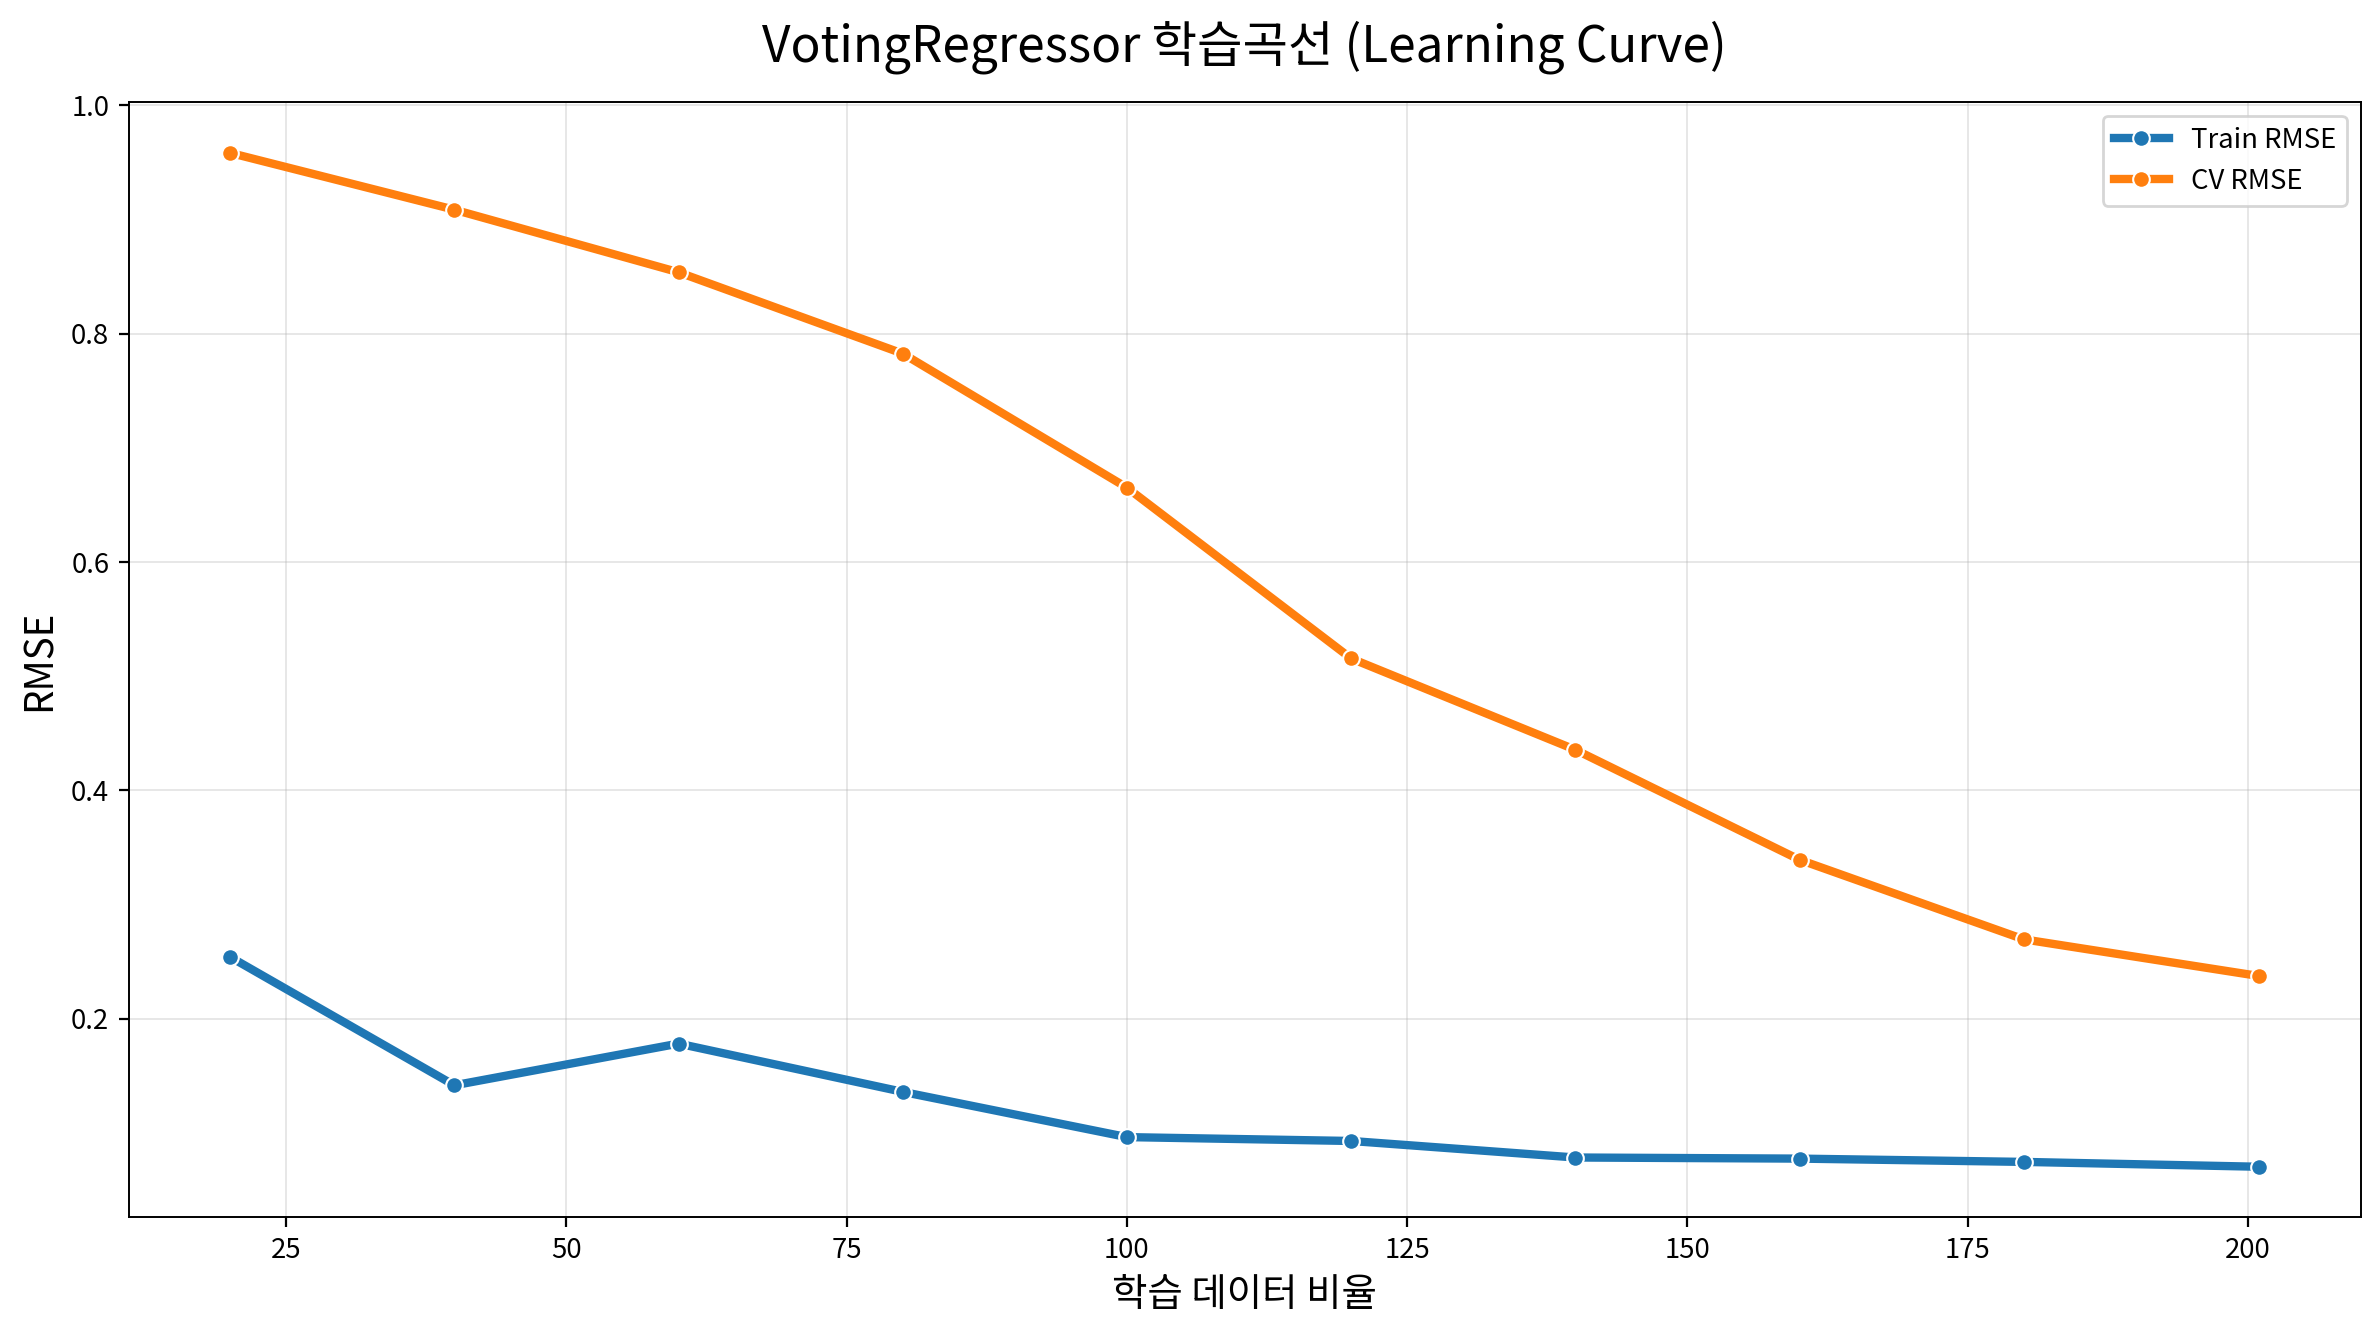

CPU times: total: 875 ms
Wall time: 13.5 s


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균제곱로그오차(MSLE),평균로그오차(RMSLE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
VotingRegressor,0.995,0.056,0.005,0.071,0.000,0.004,0.003,0.038,0.070,0.237,0.073,0.296,0.309,⚠️ 과대적합


In [221]:
%%time
hs_get_score_cv(tuned, x_train_transformed, y_train_transformed, x_transformed, y_transformed)

#### 3. 변수 중요도 확인

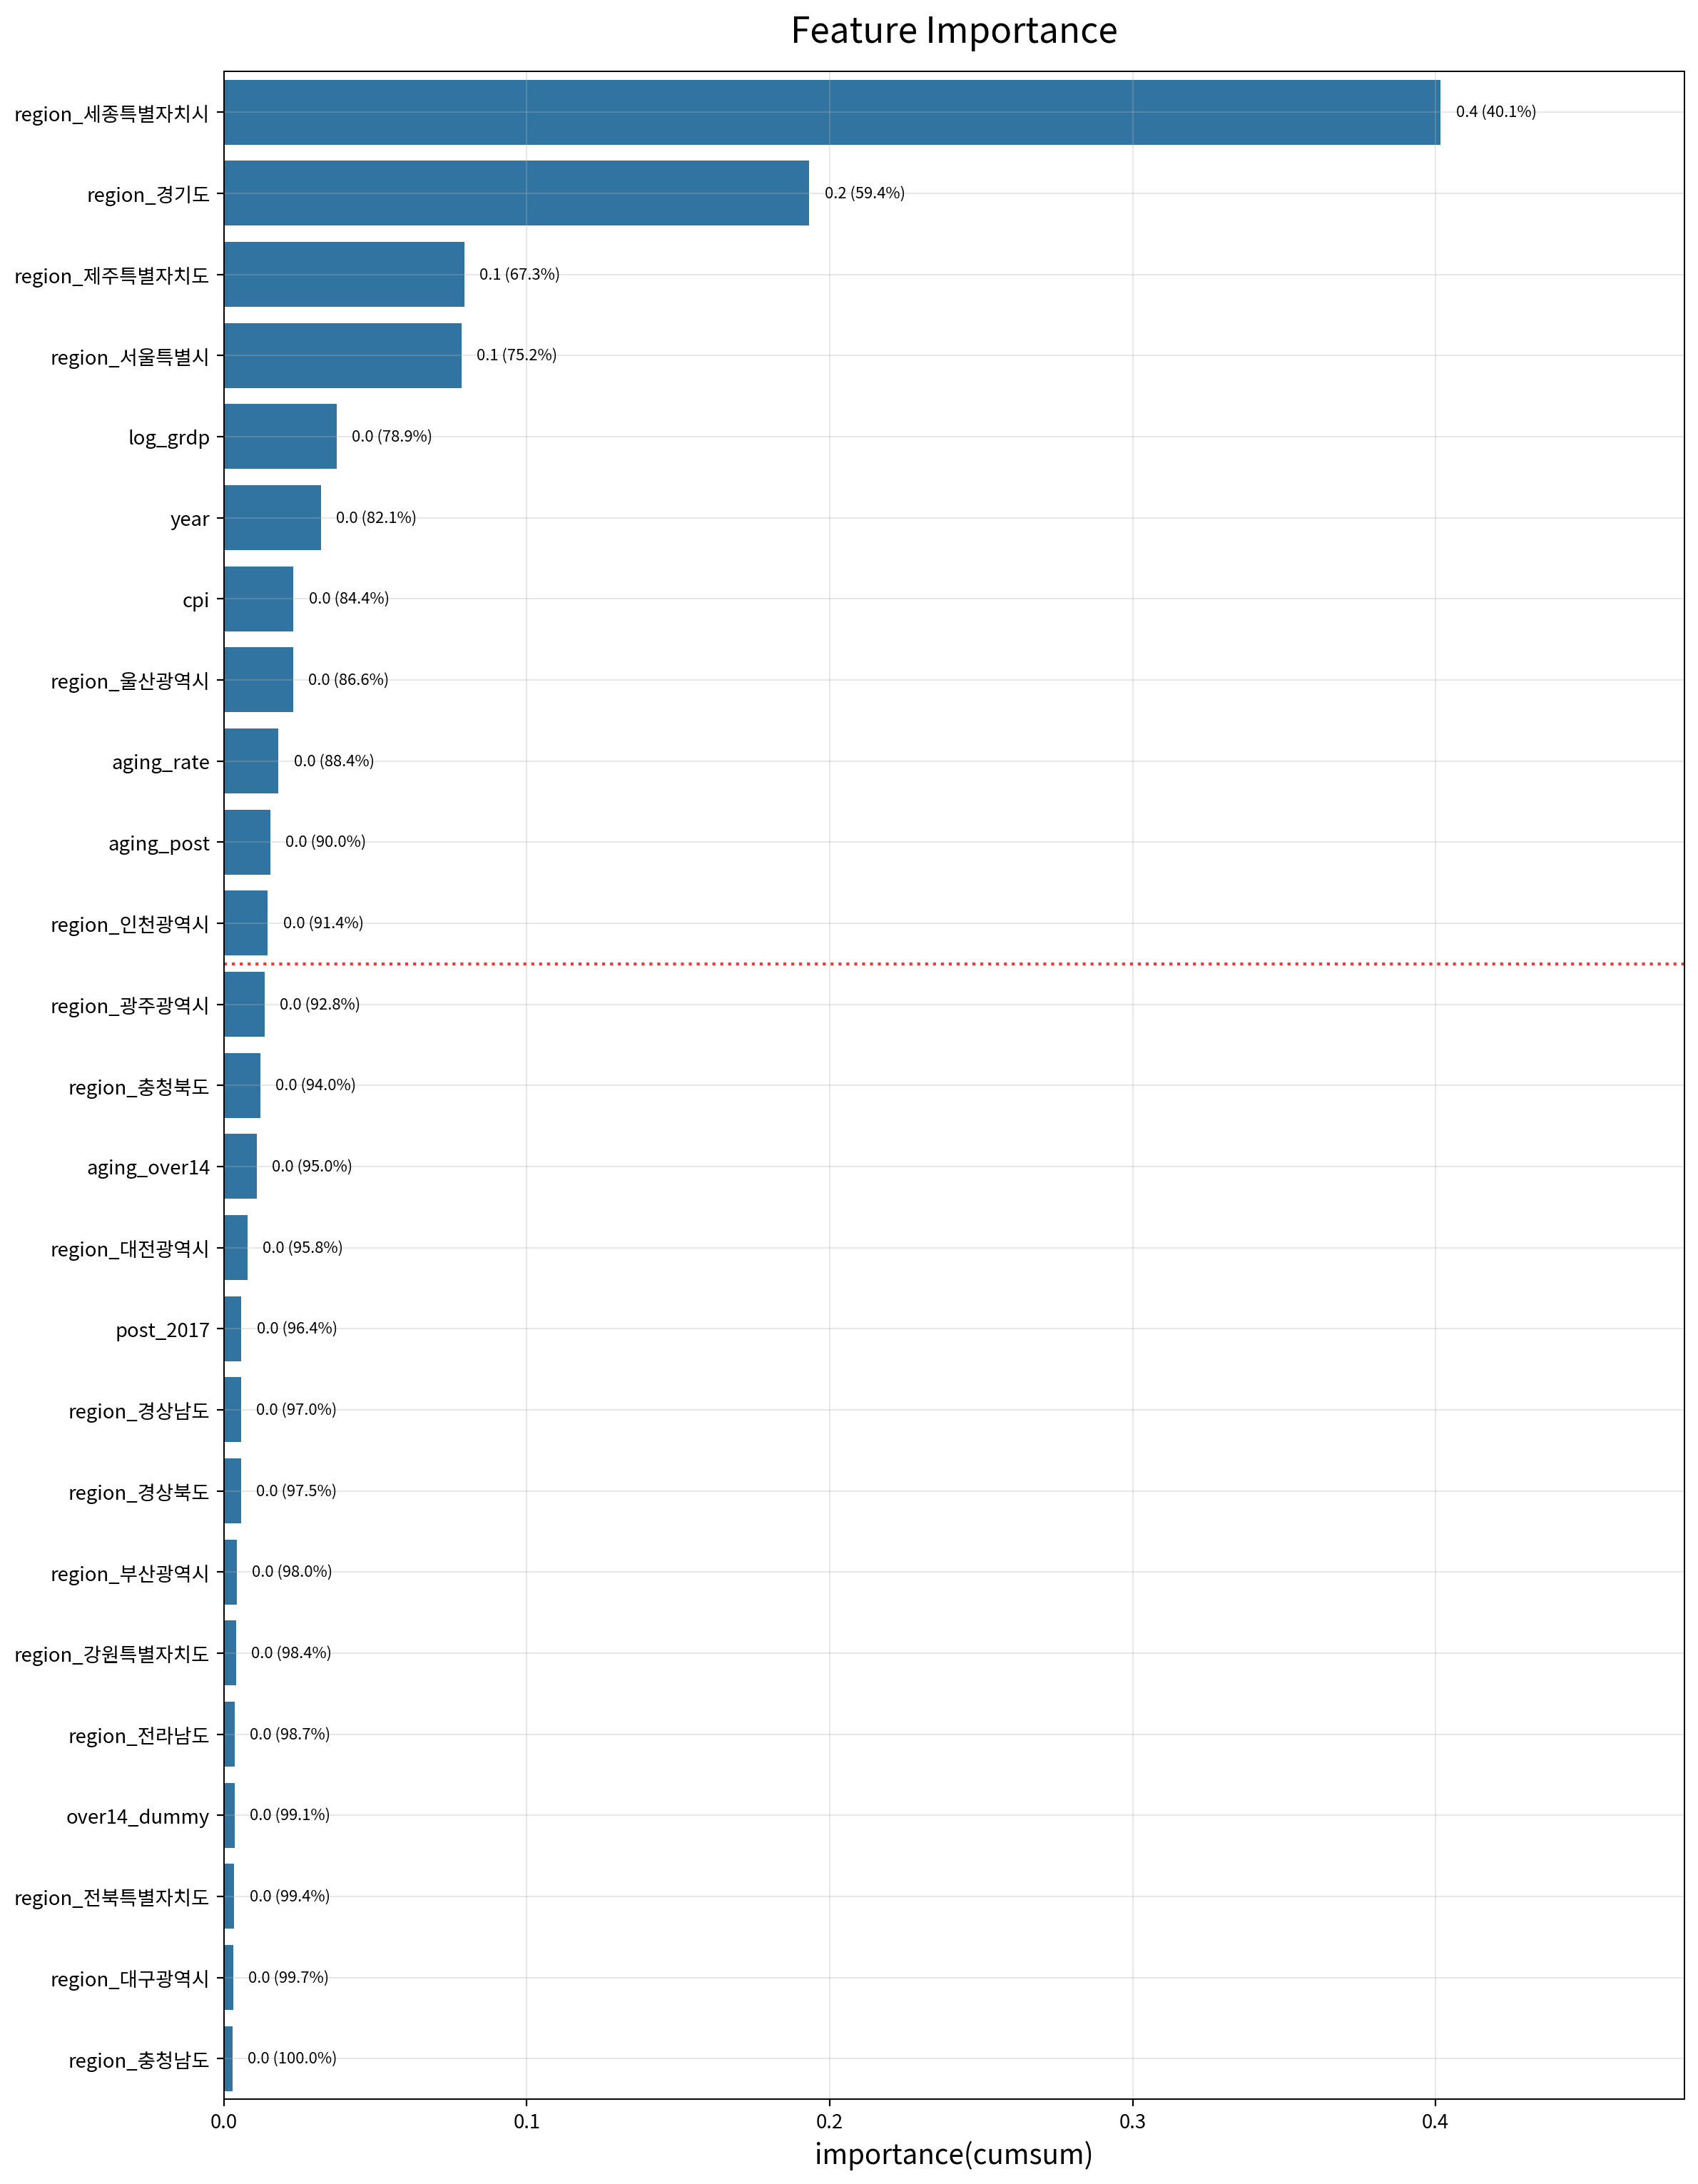

,importance,ratio,cumsum
region_세종특별자치시,0.402,0.401,0.401
region_경기도,0.193,0.193,0.594
region_제주특별자치도,0.079,0.079,0.673
region_서울특별시,0.078,0.078,0.752
log_grdp,0.037,0.037,0.789
year,0.032,0.032,0.821
cpi,0.023,0.023,0.844
region_울산광역시,0.023,0.023,0.866
aging_rate,0.018,0.018,0.884
aging_post,0.015,0.015,0.900


In [211]:
hs_feature_importance(tuned, x_train_transformed, y_train_transformed)

#### 인사이트
- 1 Feature importance 분석에서 region 더미 변수들이 가장 높은 중요도를 보였다
    - 세종, 경기도, 제주, 서울
        - 이는 장기요양보험 지출이 단순히 고령화율 증가만으로 설명되는 것이 아니라, 지역별 구조적 특성의 영향을 강하게 받는다는 것을 의미한다
- 2 지역 변수는 다음과 같은 요인을 동시에 반영할 가능성이 있다
    - 지역 경제 수준
    - 인구 규모
    - 장기요양 시설 공급 수준
    - 도시 및 농촌 구조 차이
- 즉 지역 자체가 장기요양 수요 구조를 대표하는 변수처럼 작동하고 있다.
- 3 지역 효과 제거 시 구조 변수 영향 드러남
    - region 변수를 제거한 모델에서는 다음 변수들의 중요도가 상대적으로 높게 나타남
        - log_grdp
        - aging_rate
        - aging_post
        - year
        - cpi
    - 이는 지역 경제 규모, 고령화 진행 정도, 정책 변화, 시간에 따른 구조적 증가 추세의 영향을 받는 것을 알 수 있음
- 즉 경제 규모 + 고령화가 장기요양 수요 증가의 핵심 요인임
